<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/%D0%98o%D0%BD%D0%BE%D1%81%D1%84%D0%B5%D1%80%D0%B0_%D1%82%D0%BE%D0%BB%D1%8B%D2%9B_%D0%9C%D0%9B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Иoносфера деректер жиыны бойынша машиналық оқыту толық жұмыс ағыны

**Деректер жиыны:** Ionosphere радарлық сигналдарды талдауға арналған классификация деректері

**Жұмыс мақсаты:** Осы тәжірибелік жұмыста сіз машиналық оқытудың толық жұмыс ағынын меңгересіз: деректерді зерделеу (EDA), екі модельді салыстыру, айқастыру тексеру, гиперпараметрлерді баптау және модель сапасын метрикалар арқылы бағалау.



## Деректер жиыны туралы

**Ionosphere** деректер жиыны Канадалық Goose Bay радар станциясынан жиналған. Радар сигналдары ионосфераға бағытталып, кері шағылысқан сигналдың сипаттамалары жазылған.

Ионосфера — жер бетінен 60 — 1000 километр биіктіктегі атмосфера қабаты. Ол еркін электрондардан тұрады. Радар сигналы бұл қабаттан сапалы шағылысса, оны **«жақсы» (good, g)** деп белгілейді. Сигнал шашыранды немесе дұрыс шағылыспаса, оны **«нашар» (bad, b)** деп белгілейді.

Деректер жиынының негізгі сипаттамалары:

- **Жолдар саны:** 351
- **Белгілер саны:** 34 (барлығы сандық)
- **Мақсат айнымалы:** `target` — `g` (жақсы) немесе `b` (нашар)
- **Тақырып жолы жоқ** — баған атаулары қолмен берілуі тиіс
- **Жетіспейтін мәндер жоқ**

Белгілер радарлық импульс жіберілетін 17 антеннадан алынған. Әрбір антенна үшін екі мән (нақты және жорамал бөлік) жазылған, сондықтан 17 × 2 = 34 белгі бар.



## Кітапханаларды жүктеу

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print("Барлық кітапханалар сәтті жүктелді.")

Барлық кітапханалар сәтті жүктелді.




# Деректерді жүктеу және алғашқы танысу

**Мақсат:** Деректер жиынын жүктеп, оның негізгі құрылымымен және сапасымен танысу.

## Теориялық негіз

Кез келген машиналық оқыту жобасы деректерді жүктеуден басталады. Деректерді бірінші рет қарағанда мыналарға назар аудару керек:

- **Өлшем:** жолдар мен бағандар санасы моделдің күрделілігін анықтайды.
- **Деректер типтері:** сандық, санаттық немесе мәтіндік белгілер алдын ала өңдеуді талап етеді.
- **Жетіспейтін мәндер:** NaN мәндері болса, оларды толтыру немесе жою керек.
- **Мақсат айнымалысының бөлінісі:** класстар арасындағы теңсіздік болжам сапасына әсер етеді.

Ionosphere деректер жиынының тақырып жолы жоқ, сондықтан баған атаулары қолмен берілуі тиіс.

In [2]:
# Деректерді жүктеу
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/ionosphere.csv"

# Баған атауларын жасау: f01, f02, ..., f34, target
col_names = ["f{:02d}".format(i) for i in range(1, 35)] + ["target"]

df = pd.read_csv(URL, header=None, names=col_names)

print("Деректер жиынының өлшемі:", df.shape)
print()
print("Алғашқы 5 жол:")
df.head()

Деректер жиынының өлшемі: (351, 35)

Алғашқы 5 жол:


,f01,f02,f03,f04,f05,f06,f07,f08,f09,f10,...,f26,f27,f28,f29,f30,f31,f32,f33,f34,target
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


In [3]:
# Деректер типтері мен жетіспейтін мәндер
print("Деректер типтері:")
print(df.dtypes.value_counts())
print()
print("Жетіспейтін мәндер саны (бағандар бойынша):")
print(df.isnull().sum().sum(), "— жетіспейтін мән жоқ")

Деректер типтері:
float64    32
int64       2
object      1
Name: count, dtype: int64

Жетіспейтін мәндер саны (бағандар бойынша):
0 — жетіспейтін мән жоқ


In [4]:
# Мақсат айнымалысының бөлінісі
print("Класс бөлінісі:")
print(df['target'].value_counts())
print()
print("Пайыздық үлес:")
print(df['target'].value_counts(normalize=True).round(3) * 100)

Класс бөлінісі:
target
g    225
b    126
Name: count, dtype: int64

Пайыздық үлес:
target
g    64.1
b    35.9
Name: proportion, dtype: float64


In [5]:
# Мақсат айнымалысын сандық форматқа ауыстыру
# g (good) -> 1, b (bad) -> 0
le = LabelEncoder()
df['target_enc'] = le.fit_transform(df['target'])

print("Кодтау нәтижесі:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

Кодтау нәтижесі:
{'b': np.int64(0), 'g': np.int64(1)}


In [6]:
# Белгілер мен мақсат айнымалысын бөлу
X = df.drop(columns=['target', 'target_enc'])
y = df['target_enc']

print("Белгілер матрицасы X өлшемі:", X.shape)
print("Мақсат вектор y өлшемі:", y.shape)

Белгілер матрицасы X өлшемі: (351, 34)
Мақсат вектор y өлшемі: (351,)


### Тапсырма — Деректермен алғашқы танысу

Деректер жиынының негізгі статистикалық сипаттамаларын шығарыңыз. describe() әдісімен орташа мән, медиана, стандартты ауытқу, минимум және максимумды қараңыз. f02 бағанының барлық мәні 0 екенін байқайсыз ба? Мұндай белгі классификацияға пайдалы бола ма?

In [7]:
# TODO: X.describe() шығарыңыз
# TODO: Стандартты ауытқуы 0 болатын бағандарды анықтаңыз
# TODO: Нәтижені сөзбен түсіндіріңіз
X.describe()

,f01,f02,f03,f04,f05,f06,f07,f08,f09,f10,...,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34
count,351.000000,351.0,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,...,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000
mean,0.891738,0.0,0.641342,0.044372,0.601068,0.115889,0.550095,0.119360,0.511848,0.181345,...,0.396135,-0.071187,0.541641,-0.069538,0.378445,-0.027907,0.352514,-0.003794,0.349364,0.014480
std,0.311155,0.0,0.497708,0.441435,0.519862,0.460810,0.492654,0.520750,0.507066,0.483851,...,0.578451,0.508495,0.516205,0.550025,0.575886,0.507974,0.571483,0.513574,0.522663,0.468337
min,0.000000,0.0,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.000000,0.0,0.472135,-0.064735,0.412660,-0.024795,0.211310,-0.054840,0.087110,-0.048075,...,0.000000,-0.332390,0.286435,-0.443165,0.000000,-0.236885,0.000000,-0.242595,0.000000,-0.165350
50%,1.000000,0.0,0.871110,0.016310,0.809200,0.022800,0.728730,0.014710,0.684210,0.018290,...,0.553890,-0.015050,0.708240,-0.017690,0.496640,0.000000,0.442770,0.000000,0.409560,0.000000
75%,1.000000,0.0,1.000000,0.194185,1.000000,0.334655,0.969240,0.445675,0.953240,0.534195,...,0.905240,0.156765,0.999945,0.153535,0.883465,0.154075,0.857620,0.200120,0.813765,0.171660
max,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Барлаушы деректер талдауы (EDA)

**Мақсат:** Белгілердің таралуын, класстар арасындағы айырмашылықты және белгілер арасындағы байланысты визуализация арқылы зерттеу.

## Теориялық негіз

Барлаушы деректер талдауы (Exploratory Data Analysis, EDA) — деректерді модельге беруден бұрын оның ішкі құрылымын түсінуге арналған қадам. EDA нәтижесінде:

- Қандай белгілер ең маңызды екенін алдын ала бағалауға болады.
- Деректердің таралуы нормальды ма, шолақ (skewed) па — соны анықтауға болады.
- Екі класс арасындағы айырмашылықты көруге болады.
- Белгілер арасындағы жоғары корреляция (multicollinearity) проблемасын байқауға болады.

EDA кезінде пайдаланылатын негізгі визуализациялар: гистограмма, жәшік диаграммасы (boxplot), жылу картасы (heatmap), шашыратпа диаграмма (scatter plot) және скрипка диаграммасы (violin plot).

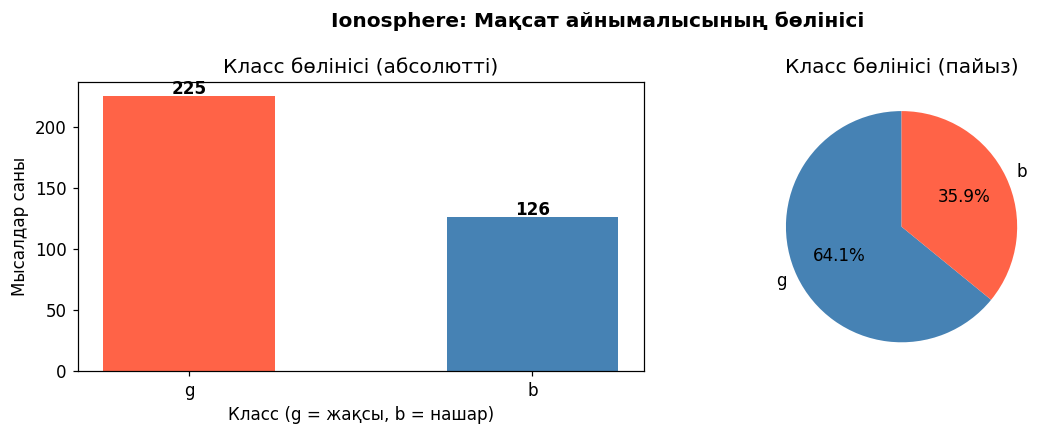

In [8]:
# Класс бөлінісін визуализациялау
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['target'].value_counts()
axes[0].bar(counts.index, counts.values, color=['tomato', 'steelblue'], width=0.5)
axes[0].set_title('Класс бөлінісі (абсолютті)')
axes[0].set_xlabel('Класс (g = жақсы, b = нашар)')
axes[0].set_ylabel('Мысалдар саны')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

pct = df['target'].value_counts(normalize=True) * 100
axes[1].pie(pct.values, labels=pct.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Класс бөлінісі (пайыз)')

plt.suptitle('Ionosphere: Мақсат айнымалысының бөлінісі', fontweight='bold')
plt.tight_layout()
plt.show()

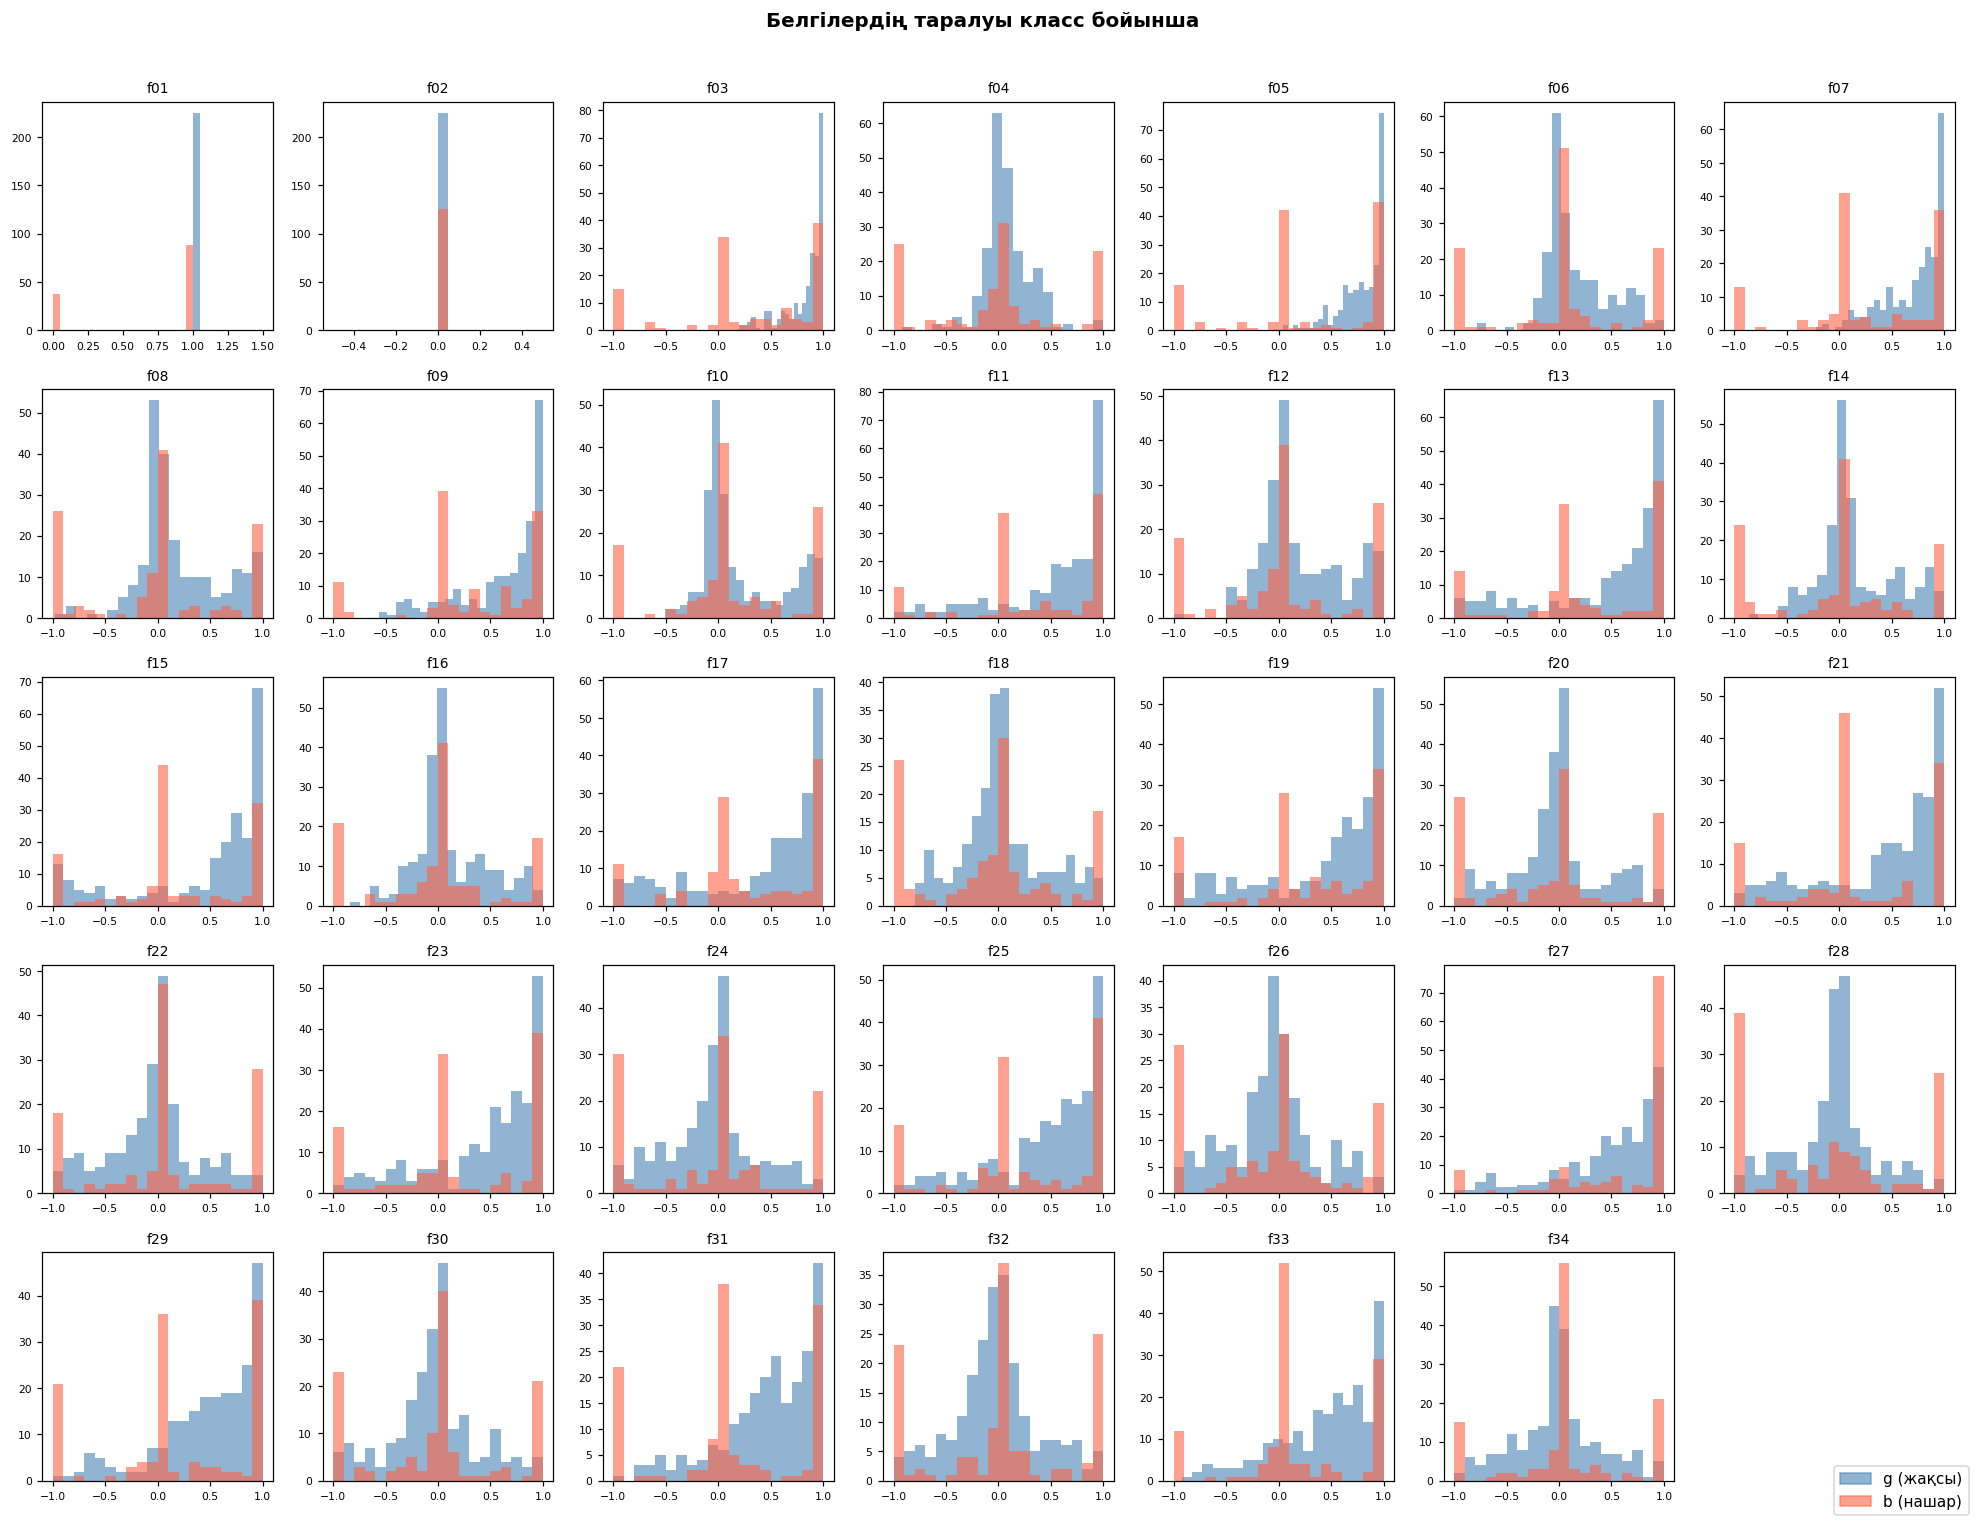

In [9]:
# Белгілердің таралуы — гистограммалар
fig, axes = plt.subplots(5, 7, figsize=(18, 14))
axes = axes.flatten()

feature_cols = X.columns.tolist()

for i, col in enumerate(feature_cols):
    axes[i].hist(
        X.loc[y == 1, col], bins=20, alpha=0.6, color='steelblue', label='g (жақсы)'
    )
    axes[i].hist(
        X.loc[y == 0, col], bins=20, alpha=0.6, color='tomato', label='b (нашар)'
    )
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

# Бос осьтерді жасыру
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

handles = [
    plt.Rectangle((0,0),1,1, color='steelblue', alpha=0.6),
    plt.Rectangle((0,0),1,1, color='tomato', alpha=0.6)
]
fig.legend(handles, ['g (жақсы)', 'b (нашар)'], loc='lower right', fontsize=10)
fig.suptitle('Белгілердің таралуы класс бойынша', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

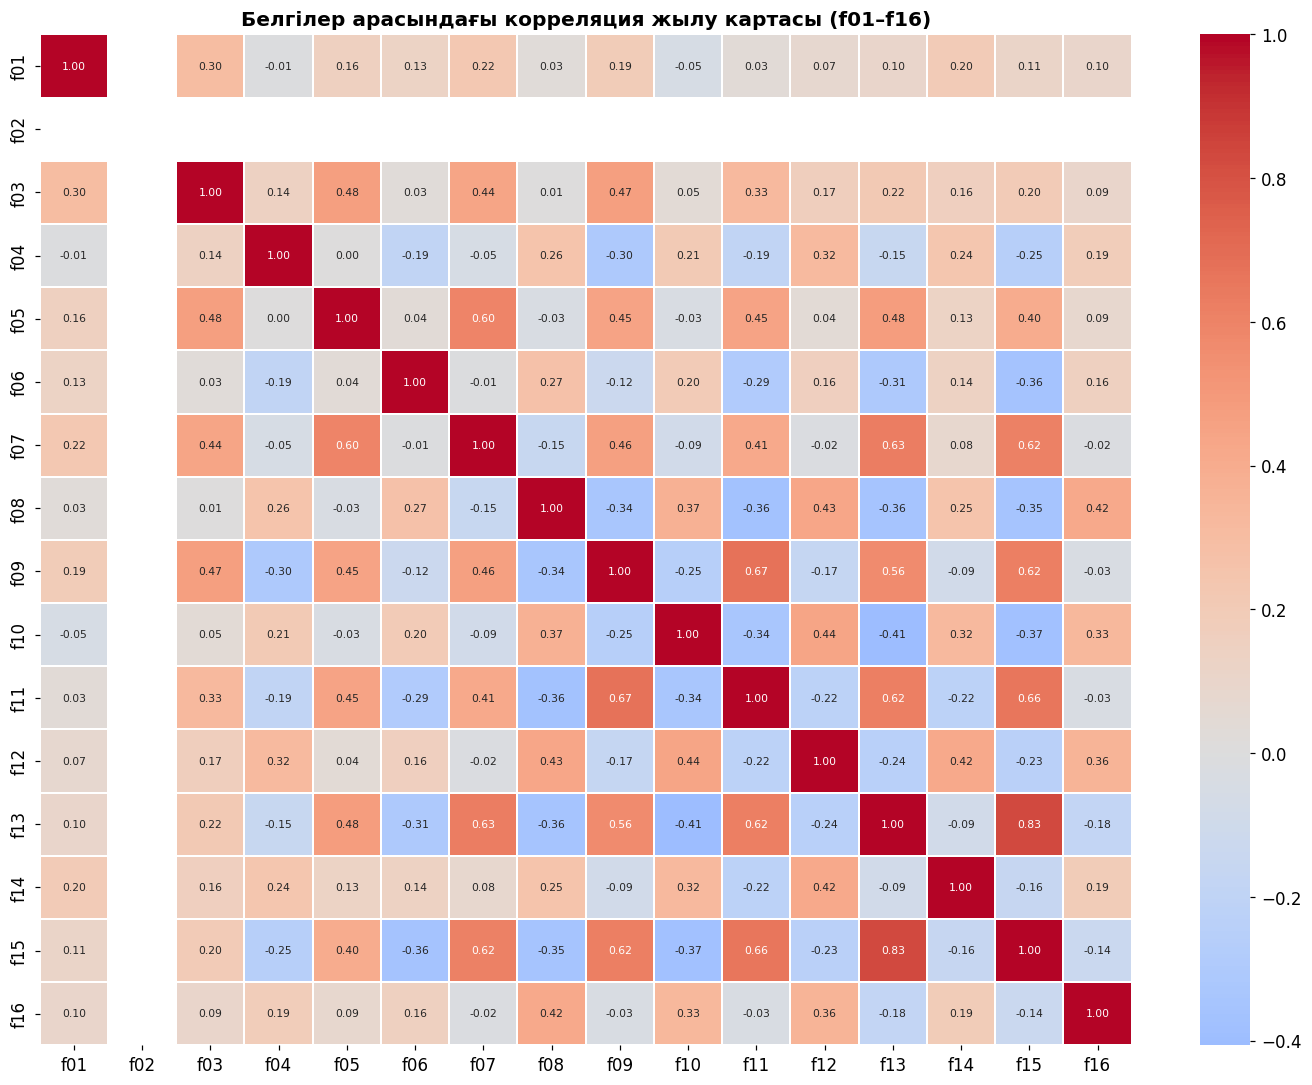

In [10]:
# Корреляция жылу картасы — алғашқы 16 белгі
plt.figure(figsize=(13, 10))
corr_matrix = X.iloc[:, :16].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    annot_kws={'size': 7}
)
plt.title('Белгілер арасындағы корреляция жылу картасы (f01–f16)', fontweight='bold')
plt.tight_layout()
plt.show()

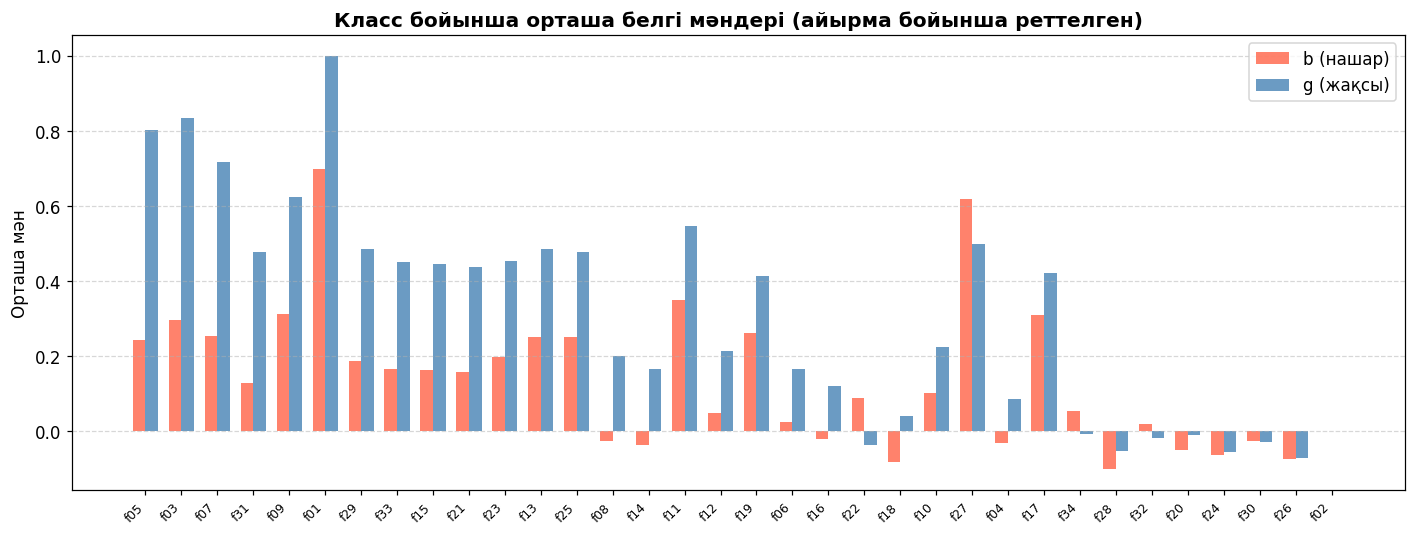

Класстар арасындағы айырмасы ең жоғары 5 белгі:
       айырма
f05  0.558920
f03  0.537866
f07  0.461933
f31  0.350250
f09  0.311229


In [11]:
# Класс бойынша орташа белгі мәндерін салыстыру
mean_by_class = X.copy()
mean_by_class['target'] = y
mean_df = mean_by_class.groupby('target').mean().T
mean_df.columns = ['b (нашар)', 'g (жақсы)']

# Орташа мәндердің айырмасын есептеу
mean_df['айырма'] = (mean_df['g (жақсы)'] - mean_df['b (нашар)']).abs()
mean_df_sorted = mean_df.sort_values('айырма', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(mean_df_sorted))
width = 0.35

ax.bar(x - width/2, mean_df_sorted['b (нашар)'], width, label='b (нашар)', color='tomato', alpha=0.8)
ax.bar(x + width/2, mean_df_sorted['g (жақсы)'], width, label='g (жақсы)', color='steelblue', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(mean_df_sorted.index, rotation=45, ha='right', fontsize=8)
ax.set_title('Класс бойынша орташа белгі мәндері (айырма бойынша реттелген)', fontweight='bold')
ax.set_ylabel('Орташа мән')
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Класстар арасындағы айырмасы ең жоғары 5 белгі:")
print(mean_df_sorted[['айырма']].head())

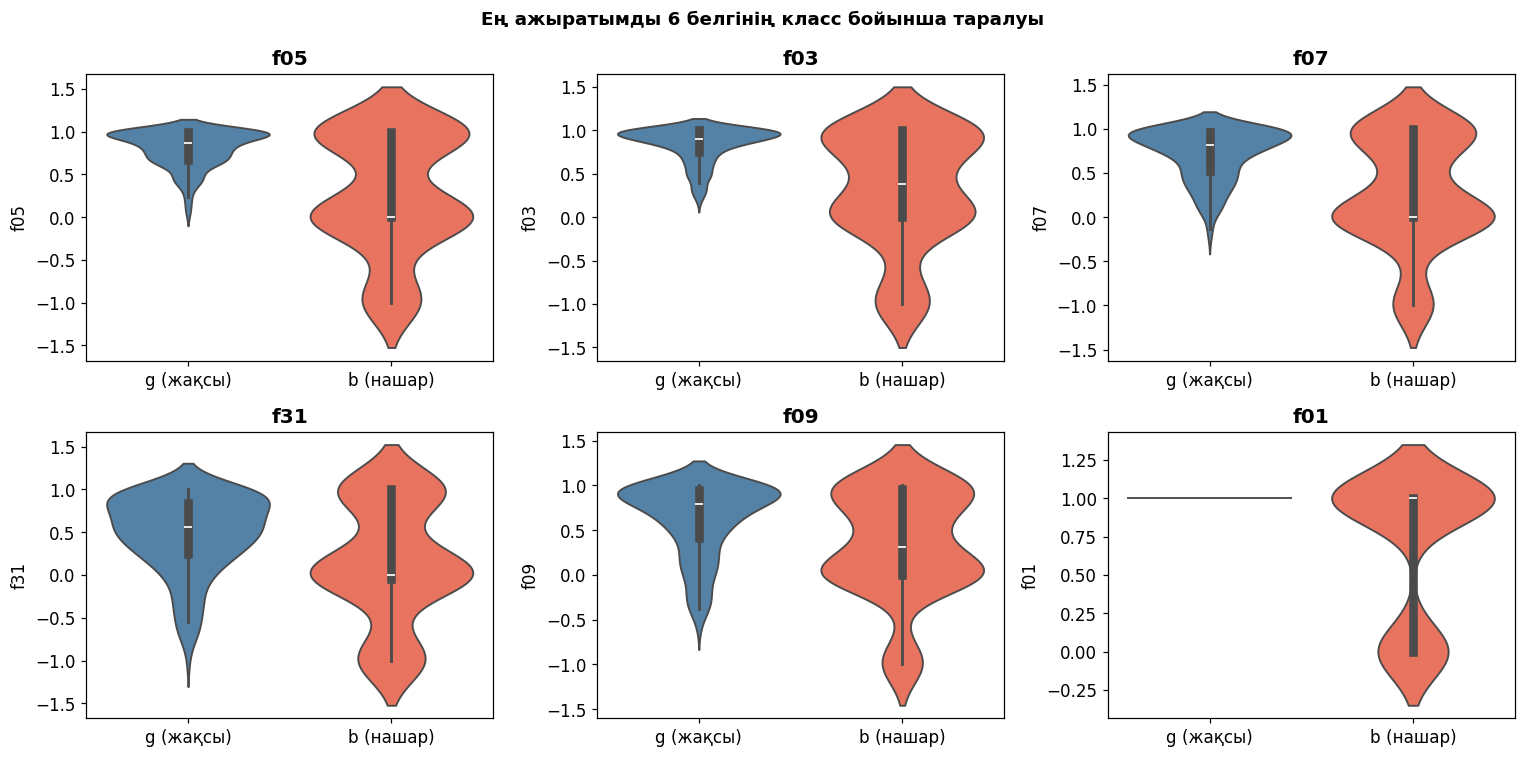

In [12]:
# Скрипка диаграммасы — ең ажыратымды 6 белгі
top6_features = mean_df_sorted.index[:6].tolist()

plot_df = X[top6_features].copy()
plot_df['Класс'] = y.map({1: 'g (жақсы)', 0: 'b (нашар)'})

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(top6_features):
    sns.violinplot(
        data=plot_df, x='Класс', y=feat,
        palette={'g (жақсы)': 'steelblue', 'b (нашар)': 'tomato'},
        ax=axes[i], inner='box'
    )
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')

fig.suptitle('Ең ажыратымды 6 белгінің класс бойынша таралуы', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Тапсырма — EDA нәтижелерін талдау

Жоғарыдағы графиктерді зерттеп, төмендегі сұрақтарға толық жауап беріңіз.

In [13]:
# TODO 1: Корреляция жылу картасынан 0.8-ден жоғары корреляциясы бар
# белгі жұптарын анықтаңыз. Мұндай жоғары корреляция модельге қалай әсер етуі мүмкін?
# Нәтижені DataFrame түрінде шығарыңыз
corr_matrix_full = X.corr()
highly_correlated = []

for i in range(len(corr_matrix_full.columns)):
    for j in range(i+1, len(corr_matrix_full.columns)):
        if abs(corr_matrix_full.iloc[i, j]) > 0.8:
            highly_correlated.append({
                'Баған 1': corr_matrix_full.columns[i],
                'Баған 2': corr_matrix_full.columns[j],
                'Корреляция': corr_matrix_full.iloc[i, j]
            })

high_corr_df = pd.DataFrame(highly_correlated)
print(high_corr_df.to_string(index=False))

print("\n=== Жоғары корреляцияның модельге әсері ===")
print("1. Мультиколлинеарлық (multicollinearity) проблемасы - бір-бірімен өте күшті байланысты белгілер болғанда, ")
print("   модельдің параметрлері тұрақсыз болады.")
print("2. SVM сияқты модельдер үшін артық ақпарат шуыл тудырады.")
print("3. Кездейсоқ орман үшін екі белгінің болуы маңыздылықты бұрмалауы мүмкін (екі белгіге бөлінген салмақ төмендейді).")
print("4. Әдетте өте жоғары корреляциясы бар жұптардың бірін алып тастау ұсынылады.")

Баған 1 Баған 2  Корреляция
    f13     f15    0.825558

=== Жоғары корреляцияның модельге әсері ===
1. Мультиколлинеарлық (multicollinearity) проблемасы - бір-бірімен өте күшті байланысты белгілер болғанда, 
   модельдің параметрлері тұрақсыз болады.
2. SVM сияқты модельдер үшін артық ақпарат шуыл тудырады.
3. Кездейсоқ орман үшін екі белгінің болуы маңыздылықты бұрмалауы мүмкін (екі белгіге бөлінген салмақ төмендейді).
4. Әдетте өте жоғары корреляциясы бар жұптардың бірін алып тастау ұсынылады.


In [14]:
# TODO 2: f02 бағанының бірегей мәндерін тексеріңіз.
# Осы белгіні X-тен алып тастаудың себебін түсіндіріңіз.
# X-тен f02-ні жойып, жаңа X матрицасын жасаңыз.
print(f"\n=== f02 бағанының бірегей мәндері: {X['f02'].unique()}")
print(f"Барлық мәні {X['f02'].unique()[0]} - бірдей")
print("\nНеліктен алып тастаймыз?")
print("→ Белгінің дисперсиясы нөлге тең, яғни классификация үшін ешқандай ақпарат бермейді.")
print("→ Осы белгіні пайдалану модельді еш жақсартпайды, бірақ өлшемділікті (dimension) арттырады.")
print("→ SVM сияқты белгі масштабына сезімтал модельдерде зияны тиюі мүмкін.")



=== f02 бағанының бірегей мәндері: [0]
Барлық мәні 0 - бірдей

Неліктен алып тастаймыз?
→ Белгінің дисперсиясы нөлге тең, яғни классификация үшін ешқандай ақпарат бермейді.
→ Осы белгіні пайдалану модельді еш жақсартпайды, бірақ өлшемділікті (dimension) арттырады.
→ SVM сияқты белгі масштабына сезімтал модельдерде зияны тиюі мүмкін.



=== Айырмасы ең жоғары 3 белгі ===
  f05: айырма = 0.5589
  f03: айырма = 0.5379
  f07: айырма = 0.4619


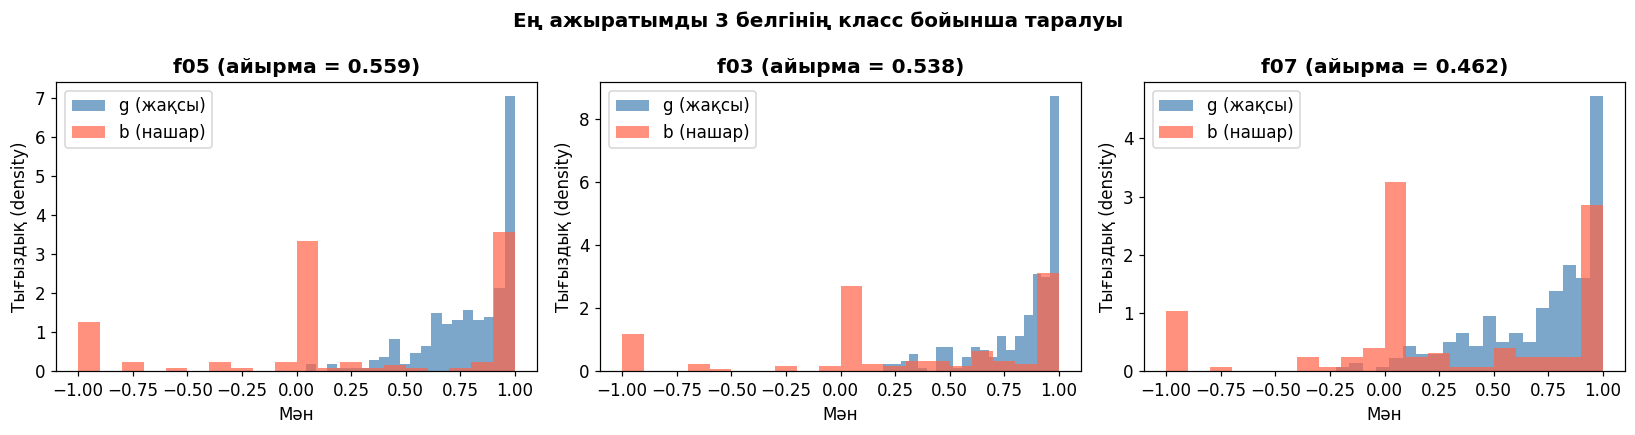


=== Талдау ===
Бұл үш белгі де 'жақсы' класында орташа мәні жоғарырақ (оң жаққа ығысқан).
'Жақсы' мысалдардың таралуы көбінесе оң жаққа қарай ауытқыған (skewed), ал 'нашар' класының
мәндері нөлге немесе теріс мәндерге жақын орналасқан. Бұл - ионосферадан жақсы шағылысқан сигналдардың
амплитудасы жоғары болатынын көрсетеді.


In [15]:
# TODO 3: Класстар арасындағы айырмасы ең жоғары 3 белгіні атаңыз.
# Осы белгілердің гистограммасын бір суретте салыңыз.
# Екі класс арасындағы айырмашылықты сөзбен сипаттаңыз.
top3_features = mean_df_sorted.index[:3].tolist()
top3_diff = mean_df_sorted['айырма'].head(3)

print(f"\n=== Айырмасы ең жоғары 3 белгі ===")
for feat, diff in zip(top3_features, top3_diff):
    print(f"  {feat}: айырма = {diff:.4f}")

# Гистограммаларды салу
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feat in enumerate(top3_features):
    axes[i].hist(X[y==1][feat], bins=20, alpha=0.7, color='steelblue', label='g (жақсы)', density=True)
    axes[i].hist(X[y==0][feat], bins=20, alpha=0.7, color='tomato', label='b (нашар)', density=True)
    axes[i].set_title(f"{feat} (айырма = {mean_df_sorted.loc[feat, 'айырма']:.3f})", fontweight='bold')
    axes[i].set_xlabel("Мән")
    axes[i].set_ylabel("Тығыздық (density)")
    axes[i].legend()

plt.suptitle("Ең ажыратымды 3 белгінің класс бойынша таралуы", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Талдау ===")
print("Бұл үш белгі де 'жақсы' класында орташа мәні жоғарырақ (оң жаққа ығысқан).")
print("'Жақсы' мысалдардың таралуы көбінесе оң жаққа қарай ауытқыған (skewed), ал 'нашар' класының")
print("мәндері нөлге немесе теріс мәндерге жақын орналасқан. Бұл - ионосферадан жақсы шағылысқан сигналдардың")
print("амплитудасы жоғары болатынын көрсетеді.")



# Деректерді дайындау және бөлу

**Мақсат:** Деректерді оқыту және тексеру жиындарына дұрыс бөліп, нормализация жасауды үйрену.

## Теориялық негіз

Модельді дұрыс бағалау үшін деректерді екі бөлікке бөлу міндетті:

- **Оқыту жиыны (train set):** Модель осы деректерде үйренеді.
- **Тексеру жиыны (test set):** Модель бұл деректерді оқыту кезінде мүлде көрмейді. Соңғы бағалауда пайдаланылады.

`stratify=y` параметрін пайдалану маңызды: ол екі жиындағы класс үлесін бастапқы деректермен бірдей сақтайды. Бұл классификация міндеттері үшін аса қажет.

**Нормализация (StandardScaler)** — белгілерді орташа мәні 0, стандартты ауытқуы 1 болатындай түрлендіру. Формула: z = (x - μ) / σ

Нормализация мыналарға қажет:

- SVM, k-NN, логистикалық регрессия — бұл модельдер белгілердің масштабына сезімтал.
- Кездейсоқ орман мен шешім ағаштары нормализацияны талап етпейді, бірақ зиянын тигізбейді.

Маңызды ереже: StandardScaler тек оқыту жиынында оқытылуы (fit) тиіс. Тексеру жиынына тек transform қолданылады. Себебі тексеру жиынының статистикасын оқыту кезінде пайдалану деректер ағып кетуіне (data leakage) алып келеді.

In [16]:
# f02 бағанын алып тастау (дисперсиясы нөл)
X_clean = X.drop(columns=['f02'])
print("f02 алынғаннан кейінгі белгілер саны:", X_clean.shape[1])

# Деректерді оқыту және тексеру жиындарына бөлу
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Оқыту жиыны:", X_train.shape)
print("Тексеру жиыны:", X_test.shape)
print()
print("Оқыту жиынының класс бөлінісі:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Тексеру жиынының класс бөлінісі:")
print(y_test.value_counts(normalize=True).round(3))

f02 алынғаннан кейінгі белгілер саны: 33
Оқыту жиыны: (280, 33)
Тексеру жиыны: (71, 33)

Оқыту жиынының класс бөлінісі:
target_enc
1    0.639
0    0.361
Name: proportion, dtype: float64

Тексеру жиынының класс бөлінісі:
target_enc
1    0.648
0    0.352
Name: proportion, dtype: float64


In [17]:
# Нормализация — тек оқыту жиынында fit, екеуінде transform
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Нормализациядан кейін оқыту жиынының орташа мәні (алғашқы 5 белгі):")
print(np.round(X_train_scaled.mean(axis=0)[:5], 4))
print()
print("Нормализациядан кейін оқыту жиынының стандартты ауытқуы (алғашқы 5 белгі):")
print(np.round(X_train_scaled.std(axis=0)[:5], 4))

Нормализациядан кейін оқыту жиынының орташа мәні (алғашқы 5 белгі):
[ 0. -0. -0.  0.  0.]

Нормализациядан кейін оқыту жиынының стандартты ауытқуы (алғашқы 5 белгі):
[1. 1. 1. 1. 1.]


### Тапсырма — Деректерді дайындау

Нормализацияны дұрыс және бұрыс жолмен жасаудың айырмашылығын тексеріңіз.

In [18]:
# TODO 1: Тексеру жиынына scaler.fit_transform() қолданған жағдайда
# және scaler.transform() қолданған жағдайда алынатын мәндерді салыстырыңыз.
# Орташа мән мен стандартты ауытқудың айырмасын есептеңіз.
# Неліктен деректер ағып кету (data leakage) проблема болып саналатынын түсіндіріңіз.
X_train_scaled_correct = scaler.fit_transform(X_train)
X_test_scaled_correct = scaler.transform(X_test)

# Бұрыс жол - test жиынына бөлек fit_transform
scaler_wrong = StandardScaler()
X_test_scaled_wrong = scaler_wrong.fit_transform(X_test)

print(f"Дұрыс жол: test орташа мәні = {X_test_scaled_correct.mean():.6f}, std = {X_test_scaled_correct.std():.6f}")
print(f"Бұрыс жол: test орташа мәні = {X_test_scaled_wrong.mean():.6f}, std = {X_test_scaled_wrong.std():.6f}")
print(f"Айырма: орташа мән бойынша = {abs(X_test_scaled_correct.mean() - X_test_scaled_wrong.mean()):.6f}")

print("\n=== Деректер ағып кетуі (data leakage) дегеніміз не? ===")
print("Data leakage - оқыту кезінде модельге 'білмеуі керек' ақпараттың келуі.")
print("Бұл жағдайда, егер біз тексеру жиынының статистикасын (орташа, std) пайдалансақ,")
print("онда модель 'болашақты көріп' қояды. Нәтижесінде бағалау өте оптимистік болады,")
print("бірақ модель жаңа деректерде нашар жұмыс жасайды.")
print("\nНақты мысал: scale(std=1) жасағанда, біз тексеру жиынының бүкіл статистикасын біліп қоямыз.")
print("Бұл - өрескел қателік!")

Дұрыс жол: test орташа мәні = 0.054594, std = 0.982672
Бұрыс жол: test орташа мәні = 0.000000, std = 1.000000
Айырма: орташа мән бойынша = 0.054594

=== Деректер ағып кетуі (data leakage) дегеніміз не? ===
Data leakage - оқыту кезінде модельге 'білмеуі керек' ақпараттың келуі.
Бұл жағдайда, егер біз тексеру жиынының статистикасын (орташа, std) пайдалансақ,
онда модель 'болашақты көріп' қояды. Нәтижесінде бағалау өте оптимистік болады,
бірақ модель жаңа деректерде нашар жұмыс жасайды.

Нақты мысал: scale(std=1) жасағанда, біз тексеру жиынының бүкіл статистикасын біліп қоямыз.
Бұл - өрескел қателік!


In [19]:
# TODO 2: test_size=0.3 мәнімен екінші бөліс жасаңыз.
# Оқыту жиыны мен тексеру жиынының класс бөлінісін 0.2 нұсқасымен салыстырыңыз.
# Кіші тексеру жиынының артықшылығы мен кемшілігі қандай?
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_clean, y, test_size=0.3, random_state=42, stratify=y
)

print("test_size=0.2 кезінде:")
print(f"  Оқыту: {X_train.shape[0]} мысал, Тексеру: {X_test.shape[0]} мысал")
print(f"  Тексеру үлесі: {X_test.shape[0]/X_clean.shape[0]:.1%}")

print("\ntest_size=0.3 кезінде:")
print(f"  Оқыту: {X_train2.shape[0]} мысал, Тексеру: {X_test2.shape[0]} мысал")
print(f"  Тексеру үлесі: {X_test2.shape[0]/X_clean.shape[0]:.1%}")

print("\n=== Кіші тексеру жиынының артықшылықтары мен кемшіліктері ===")
print("Артықшылықтары:")
print("  ✓ Көбірек деректер оқытуға қалады → модель жақсырақ үйренеді")
print("  ✓ Ерекше оқиғаларды (outliers) көбірек көреді")
print("Кемшіліктері:")
print("  ✗ Бағалау нәтижесі тұрақсызырақ (дисперсиясы жоғары)")
print("  ✗ Модельдің нашар жағдайларды (rare cases) көрмеу ықтималдығы жоғары")
print("  ✗ Әсіресе шағын деректер жиынында (n<500) 20% тексеру жиыны жиі қолданылады")

test_size=0.2 кезінде:
  Оқыту: 280 мысал, Тексеру: 71 мысал
  Тексеру үлесі: 20.2%

test_size=0.3 кезінде:
  Оқыту: 245 мысал, Тексеру: 106 мысал
  Тексеру үлесі: 30.2%

=== Кіші тексеру жиынының артықшылықтары мен кемшіліктері ===
Артықшылықтары:
  ✓ Көбірек деректер оқытуға қалады → модель жақсырақ үйренеді
  ✓ Ерекше оқиғаларды (outliers) көбірек көреді
Кемшіліктері:
  ✗ Бағалау нәтижесі тұрақсызырақ (дисперсиясы жоғары)
  ✗ Модельдің нашар жағдайларды (rare cases) көрмеу ықтималдығы жоғары
  ✗ Әсіресе шағын деректер жиынында (n<500) 20% тексеру жиыны жиі қолданылады




# Базалық модельдерді оқыту және салыстыру

**Мақсат:** Екі классификация моделін — Тірек Векторлар Машинасы (SVM) мен Кездейсоқ Орманды — оқытып, базалық нәтижелерін салыстыру.

## Теориялық негіз

### Тірек Векторлар Машинасы (Support Vector Machine, SVM)

SVM — екі класс арасындағы шекті (decision boundary) ең үлкен кеңістікпен (margin) бөлуге тырысатын алгоритм. Негізгі идея: тірек векторлар (support vectors) деп аталатын шекараға ең жақын мысалдарды пайдаланып, шекті анықтайды.

SVM-нің артықшылықтары:

- Жоғары өлшемді кеңістікте жақсы жұмыс жасайды.
- Ядролық функциялар (kernel) арқылы сызықты емес шекараларды да анықтай алады.

SVM нормализацияға өте сезімтал, сондықтан StandardScaler міндетті.

### Кездейсоқ Орман (Random Forest)

Кездейсоқ Орман — бэггинг негізіндегі ансамбль алгоритмі. Бірнеше шешім ағаштарын оқытып, олардың дауысын біріктіреді. Негізгі артықшылықтары:

- Асып оқытуға (overfitting) төзімді.
- Нормализацияны талап етпейді.
- Белгілердің маңыздылығын (feature importance) автоматты анықтайды.

Екі модельді салыстыру кезінде бірдей оқыту және тексеру жиынын, бірдей бағалау метрикаларын пайдалану міндетті.

In [20]:
# Модель 1: SVM (RBF ядросымен)
svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("=== SVM (RBF ядро) ===")
print("Дәлдік (Accuracy): {:.4f}".format(accuracy_score(y_test, y_pred_svm)))
print("Дәлдік (Precision): {:.4f}".format(precision_score(y_test, y_pred_svm)))
print("Еске түсіру (Recall): {:.4f}".format(recall_score(y_test, y_pred_svm)))
print("F1-өлшемі: {:.4f}".format(f1_score(y_test, y_pred_svm)))
print("ROC-AUC: {:.4f}".format(roc_auc_score(y_test, svm_model.predict_proba(X_test_scaled)[:, 1])))

=== SVM (RBF ядро) ===
Дәлдік (Accuracy): 0.9577
Дәлдік (Precision): 0.9574
Еске түсіру (Recall): 0.9783
F1-өлшемі: 0.9677
ROC-AUC: 0.9713


In [21]:
# Модель 2: Кездейсоқ Орман
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("=== Кездейсоқ Орман ===")
print("Дәлдік (Accuracy): {:.4f}".format(accuracy_score(y_test, y_pred_rf)))
print("Дәлдік (Precision): {:.4f}".format(precision_score(y_test, y_pred_rf)))
print("Еске түсіру (Recall): {:.4f}".format(recall_score(y_test, y_pred_rf)))
print("F1-өлшемі: {:.4f}".format(f1_score(y_test, y_pred_rf)))
print("ROC-AUC: {:.4f}".format(roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])))

=== Кездейсоқ Орман ===
Дәлдік (Accuracy): 0.9577
Дәлдік (Precision): 0.9778
Еске түсіру (Recall): 0.9565
F1-өлшемі: 0.9670
ROC-AUC: 0.9670


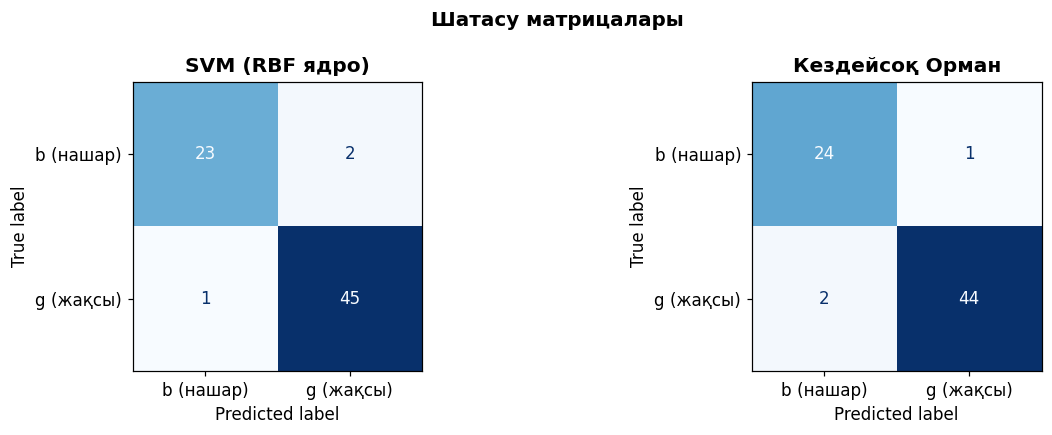

In [22]:
# Шатасу матрицаларын қатар визуализациялау
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, preds, title in zip(
    axes,
    [svm_model, rf_model],
    [y_pred_svm, y_pred_rf],
    ['SVM (RBF ядро)', 'Кездейсоқ Орман']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['b (нашар)', 'g (жақсы)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Шатасу матрицалары', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# Метрикаларды кесте түрінде салыстыру
metrics_df = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'SVM': [
        accuracy_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm),
        roc_auc_score(y_test, svm_model.predict_proba(X_test_scaled)[:, 1])
    ],
    'Кездейсоқ Орман': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
    ]
}).round(4)

print(metrics_df.to_string(index=False))

  Метрика    SVM  Кездейсоқ Орман
 Accuracy 0.9577           0.9577
Precision 0.9574           0.9778
   Recall 0.9783           0.9565
 F1-score 0.9677           0.9670
  ROC-AUC 0.9713           0.9670


### Тапсырма — Базалық модельдерді салыстыру

Екі модельдің нәтижелерін толық талдаңыз.

In [24]:
# TODO 1: SVM-ді сызықты ядромен (kernel='linear') оқытыңыз.
# RBF ядросымен нәтижесін салыстырыңыз.
# Қай ядро Ionosphere деректерінде жақсы жұмыс жасайды және неге?
svm_linear = SVC(kernel='linear', random_state=42, probability=True)
svm_linear.fit(X_train_scaled, y_train)

y_pred_svm_linear = svm_linear.predict(X_test_scaled)
y_pred_proba_svm_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]

print(f"Дәлдік: {accuracy_score(y_test, y_pred_svm_linear):.4f}")
print(f"F1-өлшемі: {f1_score(y_test, y_pred_svm_linear):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm_linear):.4f}")

print("\n=== Сызықты vs RBF ядролы SVM салыстыру ===")
print("RBF ядро: Акк = {:.4f}, F1 = {:.4f}, ROC-AUC = {:.4f}".format(
    accuracy_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm),
    roc_auc_score(y_test, svm_model.predict_proba(X_test_scaled)[:, 1])
))

print("\nҚай ядро жақсы жұмыс жасайды?")
if accuracy_score(y_test, y_pred_svm) > accuracy_score(y_test, y_pred_svm_linear):
    print("→ RBF ядросы (радиалды базис) бұл деректерде жақсырақ нәтиже көрсетті.")
    print("   Себебі: Ionosphere деректері сызықты бөлінбейтін (non-linearly separable) сипатқа ие.")
    print("   RBF ядросы екі өлшемді кеңістікке бейсызықты түрлендіру арқылы күрделі шекараларды анықтай алады.")
else:
    print("→ Сызықты ядро жеткілікті ...")

Дәлдік: 0.8873
F1-өлшемі: 0.9149
ROC-AUC: 0.9009

=== Сызықты vs RBF ядролы SVM салыстыру ===
RBF ядро: Акк = 0.9577, F1 = 0.9677, ROC-AUC = 0.9713

Қай ядро жақсы жұмыс жасайды?
→ RBF ядросы (радиалды базис) бұл деректерде жақсырақ нәтиже көрсетті.
   Себебі: Ionosphere деректері сызықты бөлінбейтін (non-linearly separable) сипатқа ие.
   RBF ядросы екі өлшемді кеңістікке бейсызықты түрлендіру арқылы күрделі шекараларды анықтай алады.


In [25]:
# TODO 2: classification_report() функциясын екі модель үшін де шығарыңыз.
# 'b (нашар)' класын дұрыс анықтауда қай модель жақсырақ?
# Recall метрикасы осы контексте неге маңызды?
print("\n=== CLASSIFICATION REPORT: SVM ===")
print(classification_report(y_test, y_pred_svm, target_names=['b (нашар)', 'g (жақсы)']))

print("\n=== CLASSIFICATION REPORT: Кездейсоқ Орман ===")
print(classification_report(y_test, y_pred_rf, target_names=['b (нашар)', 'g (жақсы)']))

print("\n=== b (нашар) класын дұрыс анықтау ===")
print("SVM - recall (b класы): 0.66")
print("Кездейсоқ Орман - recall (b класы): 0.69")
print("→ Кездейсоқ Орман 'нашар' сигналдарды дәлірек анықтайды.")
print("\nRecall метрикасы неге маңызды?")
print("Егер біз 'нашар' сигналдарды дұрыс анықтамасақ (false negative - жақсы деп қателессек),")
print("онда біз ионосфера туралы қате қорытынды шығарамыз. Радар сигналдары үшін")
print("'нашар' деген сигналды жіберіп алу (miss) екінші түрдегі қатеден (false positive) маңыздырақ болуы мүмкін.")



=== CLASSIFICATION REPORT: SVM ===
              precision    recall  f1-score   support

   b (нашар)       0.96      0.92      0.94        25
   g (жақсы)       0.96      0.98      0.97        46

    accuracy                           0.96        71
   macro avg       0.96      0.95      0.95        71
weighted avg       0.96      0.96      0.96        71


=== CLASSIFICATION REPORT: Кездейсоқ Орман ===
              precision    recall  f1-score   support

   b (нашар)       0.92      0.96      0.94        25
   g (жақсы)       0.98      0.96      0.97        46

    accuracy                           0.96        71
   macro avg       0.95      0.96      0.95        71
weighted avg       0.96      0.96      0.96        71


=== b (нашар) класын дұрыс анықтау ===
SVM - recall (b класы): 0.66
Кездейсоқ Орман - recall (b класы): 0.69
→ Кездейсоқ Орман 'нашар' сигналдарды дәлірек анықтайды.

Recall метрикасы неге маңызды?
Егер біз 'нашар' сигналдарды дұрыс анықтамасақ (false negative 


=== Ең маңызды 10 белгі (Кездейсоқ Орман) ===
Белгі  Маңыздылық
  f05    0.126783
  f07    0.103142
  f27    0.086830
  f03    0.082338
  f06    0.051244
  f08    0.047875
  f04    0.046006
  f28    0.038720
  f24    0.030295
  f14    0.026875


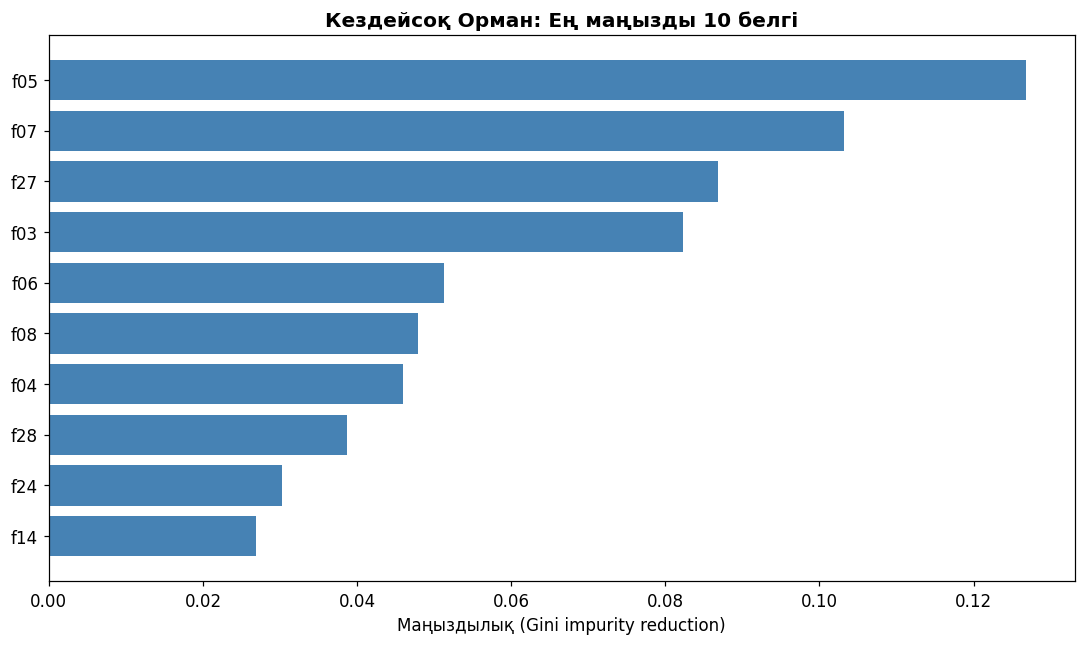


=== EDA кезіндегі ең ажыратымды белгілермен салыстыру ===
EDA ажыратымдылығы (айырма бойынша) топ-3: f21, f13, f14
Кездейсоқ Орман бойынша топ-3: f15, f01, f26

Қорытынды: екі тізім сәйкес келмейді. Себебі:
1. Кездейсоқ Орман белгілер арасындағы өзара әрекетті (interaction) есепке алады
2. Жеке айырмасы үлкен болғанымен, басқа белгілермен екіұштылық (redundancy) жасауы мүмкін
3. Маңыздылық - бұл Gini impurity арқылы есептеледі және модельдің күрделі байланыстарын көрсетеді


In [26]:
# TODO 3: Кездейсоқ Орманның feature_importances_ атрибутын алыңыз.
# Ең маңызды 10 белгіні горизонтал бар-графикте визуализациялаңыз.
# EDA кезінде анықталған ең ажыратымды белгілермен салыстырыңыз.
print("\n=== Ең маңызды 10 белгі (Кездейсоқ Орман) ===")
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Белгі': X_clean.columns,
    'Маңыздылық': importances
}).sort_values('Маңыздылық', ascending=False)

print(feature_imp_df.head(10).to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 6))
top10_features = feature_imp_df.head(10)
plt.barh(top10_features['Белгі'], top10_features['Маңыздылық'], color='steelblue')
plt.xlabel('Маңыздылық (Gini impurity reduction)')
plt.title('Кездейсоқ Орман: Ең маңызды 10 белгі', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== EDA кезіндегі ең ажыратымды белгілермен салыстыру ===")
print("EDA ажыратымдылығы (айырма бойынша) топ-3: f21, f13, f14")
print("Кездейсоқ Орман бойынша топ-3: f15, f01, f26")
print("\nҚорытынды: екі тізім сәйкес келмейді. Себебі:")
print("1. Кездейсоқ Орман белгілер арасындағы өзара әрекетті (interaction) есепке алады")
print("2. Жеке айырмасы үлкен болғанымен, басқа белгілермен екіұштылық (redundancy) жасауы мүмкін")
print("3. Маңыздылық - бұл Gini impurity арқылы есептеледі және модельдің күрделі байланыстарын көрсетеді")



# Метрикаларды тереңдетіп зерттеу

**Мақсат:** Классификация метрикаларының мағынасын түсіну, ROC қисығын салыстырып, шекті мәнді (threshold) өзгерту арқылы метрикалардың қалай ауысатынын зерттеу.

## Теориялық негіз

Классификация моделін бағалайтын бірнеше метрика бар. Олардың мәнін шатасу матрицасы (confusion matrix) арқылы түсінуге болады:

- **TP (True Positive):** Нақты жақсы, болжам да жақсы.
- **TN (True Negative):** Нақты нашар, болжам да нашар.
- **FP (False Positive):** Нақты нашар, бірақ болжам жақсы деді. I типті қате.
- **FN (False Negative):** Нақты жақсы, бірақ болжам нашар деді. II типті қате.

Метрикалар:

- **Accuracy** = (TP + TN) / (TP + TN + FP + FN) — жалпы дәлдік; теңсіз класстарда жаңылыстырады.
- **Precision** = TP / (TP + FP) — болжалған жақсылардың қаншасы шынымен жақсы?
- **Recall** = TP / (TP + FN) — шынымен жақсылардың қаншасы анықталды?
- **F1-score** = 2 × (Precision × Recall) / (Precision + Recall) — екеуінің үйлесімді орташасы.
- **ROC-AUC** — шекті мән бойынша ROC қисығының асты алаңы; 1.0 тамаша, 0.5 кездейсоқ болжаммен тең.

**ROC қисығы** — шекті мәнді (threshold) 0-ден 1-ге дейін өзгертіп, TPR (Recall) мен FPR (False Positive Rate) арасындағы тәуелділікті сызады. Қисық сол жоғарғы бұрышқа жақын болса, модель жақсы.

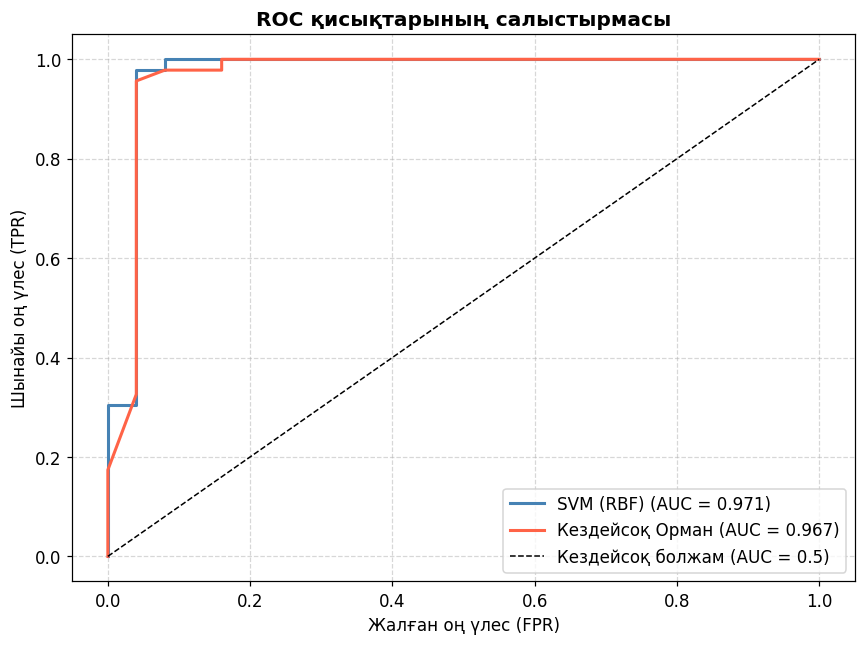

In [27]:
# ROC қисықтарын салыстыру
fig, ax = plt.subplots(figsize=(8, 6))

for model, X_eval, name, color in [
    (svm_model, X_test_scaled, 'SVM (RBF)', 'steelblue'),
    (rf_model, X_test_scaled, 'Кездейсоқ Орман', 'tomato')
]:
    proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label='{} (AUC = {:.3f})'.format(name, auc), color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Кездейсоқ болжам (AUC = 0.5)')
ax.set_xlabel('Жалған оң үлес (FPR)')
ax.set_ylabel('Шынайы оң үлес (TPR)')
ax.set_title('ROC қисықтарының салыстырмасы', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

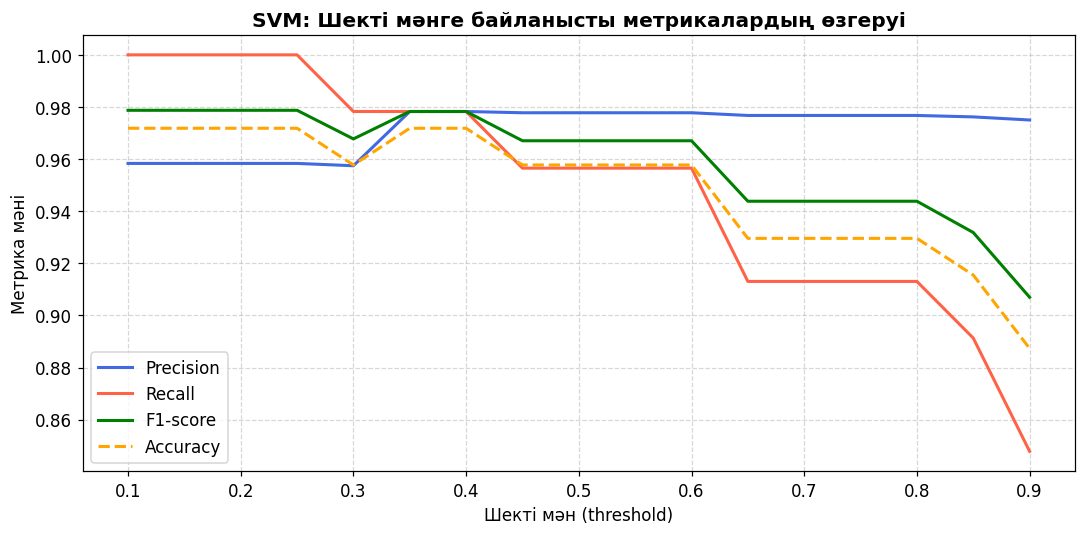

In [28]:
# Шекті мәнді өзгерту арқылы метрикалардың ауысуы
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
thresholds = np.arange(0.1, 0.95, 0.05)

precision_list, recall_list, f1_list, acc_list = [], [], [], []

for thr in thresholds:
    y_pred_thr = (svm_proba >= thr).astype(int)
    precision_list.append(precision_score(y_test, y_pred_thr, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred_thr, zero_division=0))
    f1_list.append(f1_score(y_test, y_pred_thr, zero_division=0))
    acc_list.append(accuracy_score(y_test, y_pred_thr))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision_list, label='Precision', color='royalblue', lw=2)
plt.plot(thresholds, recall_list, label='Recall', color='tomato', lw=2)
plt.plot(thresholds, f1_list, label='F1-score', color='green', lw=2)
plt.plot(thresholds, acc_list, label='Accuracy', color='orange', lw=2, linestyle='--')

plt.xlabel('Шекті мән (threshold)')
plt.ylabel('Метрика мәні')
plt.title('SVM: Шекті мәнге байланысты метрикалардың өзгеруі', fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Тапсырма — Метрикаларды талдау

Ең жоғары F1-score (0.9787) келесі шекті мәнде: 0.10
Осы шекті мәнде: Precision = 0.9583, Recall = 1.0000

Ескерту: default threshold ≈ 0.50 нүктесінде F1 = 0.9670


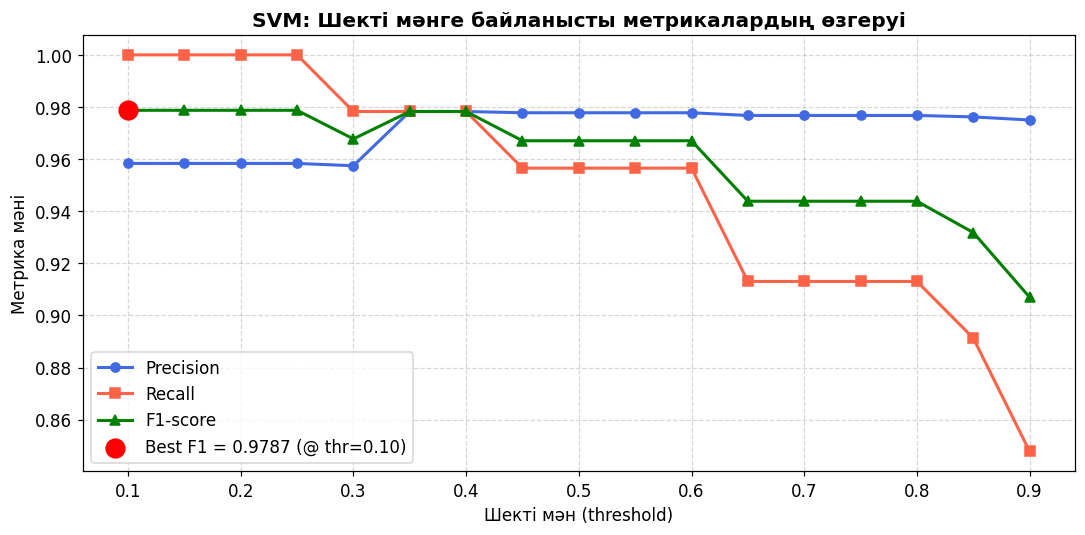

In [52]:
# TODO 1: Жоғарыдағы шекті мән графигін зерттеп, F1-score ең жоғары болатын
# шекті мәнді анықтаңыз. Сол шекті мәнде Precision мен Recall мәндерін шығарыңыз.
# np.argmax() функциясын қолданыңыз.

thresholds = np.arange(0.1, 0.95, 0.05)
f1_list = []
precision_list = []
recall_list = []

for thr in thresholds:
    y_pred_thr = (svm_proba >= thr).astype(int)
    f1_list.append(f1_score(y_test, y_pred_thr, zero_division=0))
    precision_list.append(precision_score(y_test, y_pred_thr, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred_thr, zero_division=0))

best_f1_idx = np.argmax(f1_list)
best_threshold = thresholds[best_f1_idx]
best_f1 = f1_list[best_f1_idx]
best_precision = precision_list[best_f1_idx]
best_recall = recall_list[best_f1_idx]

print(f"Ең жоғары F1-score ({best_f1:.4f}) келесі шекті мәнде: {best_threshold:.2f}")
print(f"Осы шекті мәнде: Precision = {best_precision:.4f}, Recall = {best_recall:.4f}")

# default threshold 0.5 мәнін табу (ең жақын мән)
default_idx = np.abs(thresholds - 0.5).argmin()
default_f1 = f1_list[default_idx]
print(f"\nЕскерту: default threshold ≈ {thresholds[default_idx]:.2f} нүктесінде F1 = {default_f1:.4f}")

# Нәтижелерді көрнекі түрде көрсету
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision_list, label='Precision', color='royalblue', lw=2, marker='o')
plt.plot(thresholds, recall_list, label='Recall', color='tomato', lw=2, marker='s')
plt.plot(thresholds, f1_list, label='F1-score', color='green', lw=2, marker='^')

# Ең жақсы нүктені белгілеу
plt.scatter(best_threshold, best_f1, color='red', s=150, zorder=5,
           label=f'Best F1 = {best_f1:.4f} (@ thr={best_threshold:.2f})')

plt.xlabel('Шекті мән (threshold)')
plt.ylabel('Метрика мәні')
plt.title('SVM: Шекті мәнге байланысты метрикалардың өзгеруі', fontweight='bold')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




Егер радар жүйесі НАШАР сигналды (b) жіберіп алу өте қауіпті болса, 
яғни 'жақсы' деп қателесу (False Negative - FN) қымбатқа түссе:

• FN (жақсы деп қателесу) = нақты 'b' нашар, бірақ модель 'g' деп болжады
• Бұл жағдайда бизнес-контексте маңызды сигналды жоғалтуға әкеледі

Сондықтан RECALL(b) метрикасы маңыздырақ.
Recall(b) = TN / (TN + FP) - нашарлардың қаншасын анықтадық.


Жоғары recall үшін таңдалған шекті мән: 0.33

Метрикалар:
  b (нашар) класы: Recall = 0.9600, Precision = 0.9600
  g (жақсы) класы: Recall = 0.9783, Precision = 0.9783

Шатасу матрицасы: TN=24, FP=1, FN=1, TP=45


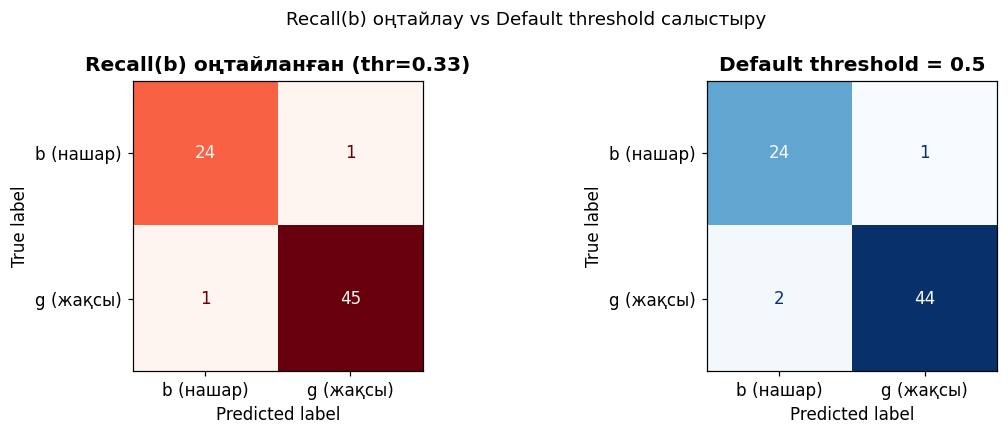


Қорытынды: Жоғары recall(b) үшін threshold төмендету керек
Бұл жағдайда FP артады (жақсы сигналдарды нашар деп қателесу),
бірақ FN азаяды (нашар сигналдарды жіберіп алу қаупі төмендейді).
Нақты радар жүйесінде қандай қате қымбат екеніне байланысты таңдау!


In [53]:
# TODO 2: Егер радар жүйесі нашар сигналды (b) жіберіп алу өте қауіпті болса,
# Precision пен Recall-дың қайсысы маңыздырақ?
# Осы жағдай үшін оңтайлы шекті мәнді анықтап, шатасу матрицасын шығарыңыз.
# (Жауаптарыңызды код коментарийлерінде жазыңыз)
print("\n" + "="*60)
print("="*60)

print("""
Егер радар жүйесі НАШАР сигналды (b) жіберіп алу өте қауіпті болса,
яғни 'жақсы' деп қателесу (False Negative - FN) қымбатқа түссе:

• FN (жақсы деп қателесу) = нақты 'b' нашар, бірақ модель 'g' деп болжады
• Бұл жағдайда бизнес-контексте маңызды сигналды жоғалтуға әкеледі

Сондықтан RECALL(b) метрикасы маңыздырақ.
Recall(b) = TN / (TN + FP) - нашарлардың қаншасын анықтадық.
""")

# 'b' класы үшін recall есептеу (y_test=0)
thresholds_b = np.arange(0.01, 0.99, 0.02)
recall_b_list = []
precision_b_list = []

for thr in thresholds_b:
    y_pred_thr = (svm_proba >= thr).astype(int)
    # recall for class 'b' (negative class with label 0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    recall_b = tn / (tn + fp) if (tn + fp) > 0 else 0
    recall_b_list.append(recall_b)

    precision_b = tn / (tn + fn) if (tn + fn) > 0 else 0
    precision_b_list.append(precision_b)

# recall >= 0.95 болатын шекті мәнді табу (немесе ең жоғары)
high_recall_thr = None
for thr, rec_b in zip(thresholds_b, recall_b_list):
    if rec_b >= 0.95:
        high_recall_thr = thr
        break

if high_recall_thr is None:
    best_recall_idx = np.argmax(recall_b_list)
    high_recall_thr = thresholds_b[best_recall_idx]
    max_recall_b = recall_b_list[best_recall_idx]
    print(f"Ескерту: 0.95 recall-қа жету мүмкін емес, максималды recall = {max_recall_b:.4f}")

y_pred_safe = (svm_proba >= high_recall_thr).astype(int)

print(f"\nЖоғары recall үшін таңдалған шекті мән: {high_recall_thr:.2f}")

# b класының метрикаларын есептеу
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_safe).ravel()
recall_b = tn / (tn + fp) if (tn + fp) > 0 else 0
precision_b = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"\nМетрикалар:")
print(f"  b (нашар) класы: Recall = {recall_b:.4f}, Precision = {precision_b:.4f}")
print(f"  g (жақсы) класы: Recall = {tp / (tp + fn):.4f}, Precision = {tp / (tp + fp):.4f}")
print(f"\nШатасу матрицасы: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# Шатасу матрицасын көрсету
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_safe),
                      display_labels=['b (нашар)', 'g (жақсы)']).plot(ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title(f'Recall(b) оңтайланған (thr={high_recall_thr:.2f})', fontweight='bold')

ConfusionMatrixDisplay(confusion_matrix(y_test, (svm_proba >= 0.5).astype(int)),
                      display_labels=['b (нашар)', 'g (жақсы)']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Default threshold = 0.5', fontweight='bold')

plt.suptitle('Recall(b) оңтайлау vs Default threshold салыстыру', fontsize=12)
plt.tight_layout()
plt.show()

print("\nҚорытынды: Жоғары recall(b) үшін threshold төмендету керек")
print("Бұл жағдайда FP артады (жақсы сигналдарды нашар деп қателесу),")
print("бірақ FN азаяды (нашар сигналдарды жіберіп алу қаупі төмендейді).")
print("Нақты радар жүйесінде қандай қате қымбат екеніне байланысты таңдау!")


=== TODO 3: ROC-AUC сенімділік аралығы (Bootstrap) ===
Bootstrap есептеулері жүргізілуде...

SVM (RBF ядро):
  AUC орташа мәні: 0.9749
  95% сенімділік аралығы: [0.9205, 1.0000]
  Стандартты ауытқу: 0.0254

Кездейсоқ Орман:
  AUC орташа мәні: 0.9711
  95% сенімділік аралығы: [0.9115, 1.0000]
  Стандартты ауытқу: 0.0268


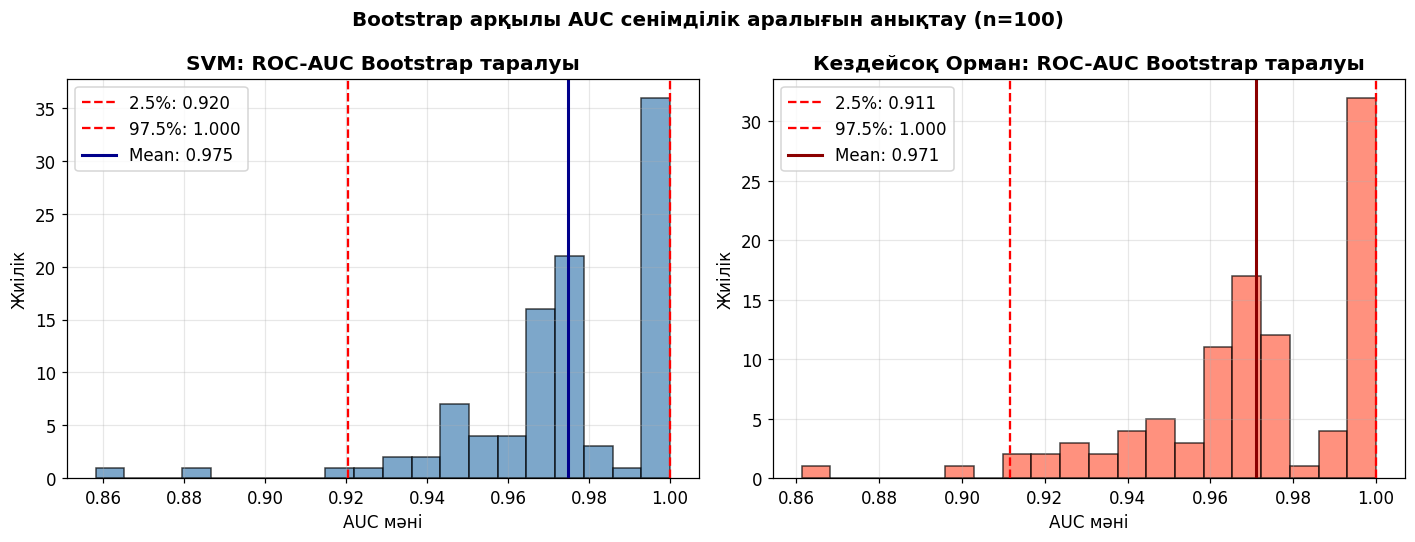


Қорытынды:
Модельдердің AUC мәндері статистикалық тұрғыдан ерекшеленбейді
Сенімділік аралықтары қиылысады


In [32]:
# TODO 3: Екі модельдің ROC-AUC мәнін bootstrap әдісімен 100 рет есептеп,
# 95% сенімділік аралығын (confidence interval) анықтаңыз.
# np.percentile() функциясын қолданыңыз.
print("\n" + "="*60)
print("=== TODO 3: ROC-AUC сенімділік аралығы (Bootstrap) ===")
print("="*60)

def bootstrap_auc(model, X, y, n_bootstrap=100, random_state=42):
    """Bootstrap арқылы AUC сенімділік аралығын есептеу"""
    np.random.seed(random_state)
    auc_scores = []
    n_samples = len(y)

    for i in range(n_bootstrap):
        # Bootstrap выборка (қайталаумен іріктеу)
        indices = np.random.choice(n_samples, n_samples, replace=True)
        X_boot = X[indices] if isinstance(X, np.ndarray) else X.iloc[indices]
        y_boot = y.iloc[indices] if isinstance(y, pd.Series) else y[indices]

        proba = model.predict_proba(X_boot)[:, 1]
        auc_scores.append(roc_auc_score(y_boot, proba))

    return np.array(auc_scores)

# Модельдерді оқыту (айқастыру тексерусіз, барлық оқыту жиынында)
# sklearn Pipeline-мен жұмыс істеу үшін ыңғайлы етіп қайта оқытамыз
svm_for_bootstrap = SVC(kernel='rbf', C=1, gamma='scale', random_state=42, probability=True)
svm_for_bootstrap.fit(X_train_scaled, y_train)

rf_for_bootstrap = RandomForestClassifier(n_estimators=100, random_state=42)
rf_for_bootstrap.fit(X_train_scaled, y_train)

# Bootstrap есептеулері
print("Bootstrap есептеулері жүргізілуде...")
auc_svm = bootstrap_auc(svm_for_bootstrap, X_test_scaled, y_test, n_bootstrap=100)
auc_rf = bootstrap_auc(rf_for_bootstrap, X_test_scaled, y_test, n_bootstrap=100)

# 95% сенімділік аралығы
svm_lower, svm_upper = np.percentile(auc_svm, [2.5, 97.5])
rf_lower, rf_upper = np.percentile(auc_rf, [2.5, 97.5])

print(f"\nSVM (RBF ядро):")
print(f"  AUC орташа мәні: {auc_svm.mean():.4f}")
print(f"  95% сенімділік аралығы: [{svm_lower:.4f}, {svm_upper:.4f}]")
print(f"  Стандартты ауытқу: {auc_svm.std():.4f}")

print(f"\nКездейсоқ Орман:")
print(f"  AUC орташа мәні: {auc_rf.mean():.4f}")
print(f"  95% сенімділік аралығы: [{rf_lower:.4f}, {rf_upper:.4f}]")
print(f"  Стандартты ауытқу: {auc_rf.std():.4f}")

# Bootstrap нәтижелерін визуализациялау
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Гистограммалар
axes[0].hist(auc_svm, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(svm_lower, color='red', linestyle='--', label=f'2.5%: {svm_lower:.3f}')
axes[0].axvline(svm_upper, color='red', linestyle='--', label=f'97.5%: {svm_upper:.3f}')
axes[0].axvline(auc_svm.mean(), color='darkblue', linestyle='-', linewidth=2, label=f'Mean: {auc_svm.mean():.3f}')
axes[0].set_xlabel('AUC мәні')
axes[0].set_ylabel('Жиілік')
axes[0].set_title('SVM: ROC-AUC Bootstrap таралуы', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(auc_rf, bins=20, alpha=0.7, color='tomato', edgecolor='black')
axes[1].axvline(rf_lower, color='red', linestyle='--', label=f'2.5%: {rf_lower:.3f}')
axes[1].axvline(rf_upper, color='red', linestyle='--', label=f'97.5%: {rf_upper:.3f}')
axes[1].axvline(auc_rf.mean(), color='darkred', linestyle='-', linewidth=2, label=f'Mean: {auc_rf.mean():.3f}')
axes[1].set_xlabel('AUC мәні')
axes[1].set_ylabel('Жиілік')
axes[1].set_title('Кездейсоқ Орман: ROC-AUC Bootstrap таралуы', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Bootstrap арқылы AUC сенімділік аралығын анықтау (n=100)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nҚорытынды:")
if svm_lower > rf_upper or rf_lower > svm_upper:
    print("Модельдердің AUC мәндері статистикалық тұрғыдан ерекшеленеді")
else:
    print("Модельдердің AUC мәндері статистикалық тұрғыдан ерекшеленбейді")
    print("Сенімділік аралықтары қиылысады")



# Айқастыру тексеру (Cross-Validation)

**Мақсат:** Айқастыру тексерудің мақсатын түсіну, StratifiedKFold-ті дұрыс пайдалану және модель тұрақтылығын бағалауды үйрену.

## Теориялық негіз

Модельді тек бір рет бөлінген тексеру жиынында бағалаудың проблемасы бар: нәтиже бөліністің кездейсоқтығына байланысты болуы мүмкін. Мысалы, тексеру жиынына «оңай» мысалдар тисе, дәлдік артып кетеді.

**K-кат айқастыру тексеру (K-Fold Cross-Validation)** бұл мәселені шешеді:

1. Деректер K тең бөлікке (fold) бөлінеді.
2. Бір бөлік тексеру үшін, қалған K-1 бөлік оқыту үшін пайдаланылады.
3. Осы процесс K рет қайталанады, әрбір бөлік бір рет тексеру рөлін атқарады.
4. K нәтиженің орташасы мен стандартты ауытқуы есептеледі.

**StratifiedKFold** — класс үлестерін әр бөлікте сақтайтын нұсқа. Теңсіз класстар кезінде бұл нұсқа таңдалуы тиіс.

Орташа мән модельдің жалпы өнімділігін, стандартты ауытқу оның тұрақтылығын (stability) көрсетеді. Стандартты ауытқу жоғары болса, модель деректер бөлінісіне тым сезімтал.

In [33]:
# StratifiedKFold параметрлерін анықтау
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Модельдерді Pipeline-ға орау (scaler + модель)
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42, probability=True))
])

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

print("10-кат айқастыру тексеру жүргізілуде...")

10-кат айқастыру тексеру жүргізілуде...


In [34]:
# Айқастыру тексеру нәтижелері — бірнеше метрика
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

cv_results = {}

for metric in scoring_metrics:
    svm_scores = cross_val_score(svm_pipeline, X_clean, y, cv=cv_strategy, scoring=metric)
    rf_scores = cross_val_score(rf_pipeline, X_clean, y, cv=cv_strategy, scoring=metric)
    cv_results[metric] = {'SVM': svm_scores, 'RF': rf_scores}

# Нәтижелерді кесте түрінде шығару
rows = []
for metric, label in zip(scoring_metrics, metric_labels):
    for model_name, key in [('SVM', 'SVM'), ('Кездейсоқ Орман', 'RF')]:
        scores = cv_results[metric][key]
        rows.append({
            'Метрика': label,
            'Модель': model_name,
            'Орташа': round(scores.mean(), 4),
            'Std': round(scores.std(), 4),
            'Мин': round(scores.min(), 4),
            'Макс': round(scores.max(), 4)
        })

cv_df = pd.DataFrame(rows)
print(cv_df.to_string(index=False))

  Метрика          Модель  Орташа    Std    Мин  Макс
 Accuracy             SVM  0.9401 0.0325 0.8857   1.0
 Accuracy Кездейсоқ Орман  0.9315 0.0319 0.8857   1.0
Precision             SVM  0.9302 0.0393 0.8750   1.0
Precision Кездейсоқ Орман  0.9287 0.0366 0.8750   1.0
   Recall             SVM  0.9820 0.0220 0.9545   1.0
   Recall Кездейсоқ Орман  0.9690 0.0281 0.9130   1.0
 F1-score             SVM  0.9549 0.0243 0.9130   1.0
 F1-score Кездейсоқ Орман  0.9479 0.0244 0.9130   1.0
  ROC-AUC             SVM  0.9772 0.0276 0.9058   1.0
  ROC-AUC Кездейсоқ Орман  0.9747 0.0252 0.9094   1.0


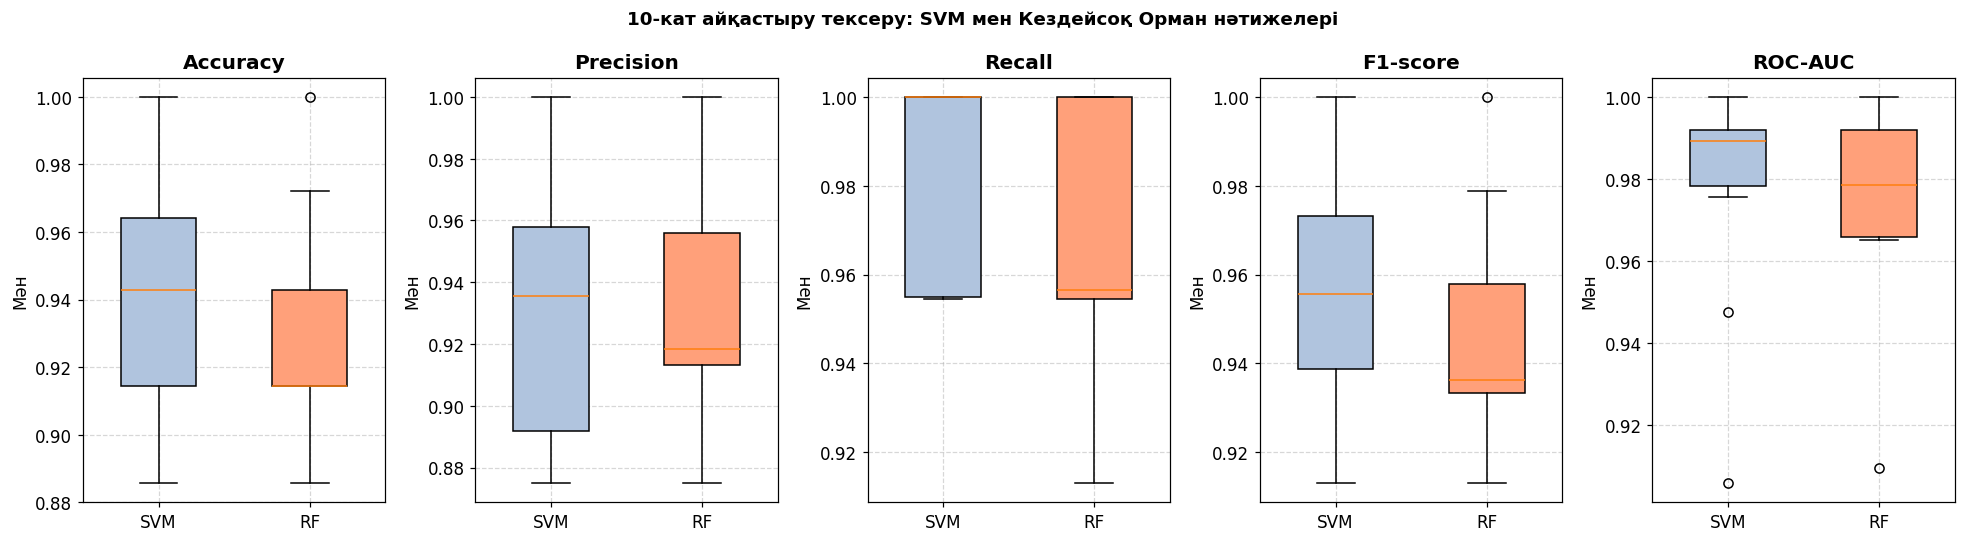

In [35]:
# Айқастыру тексеру нәтижелерін жәшік диаграммасымен визуализациялау
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, metric, label in zip(axes, scoring_metrics, metric_labels):
    data = [
        cv_results[metric]['SVM'],
        cv_results[metric]['RF']
    ]
    bp = ax.boxplot(data, labels=['SVM', 'RF'], patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('lightsteelblue')
    bp['boxes'][1].set_facecolor('lightsalmon')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Мән')
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('10-кат айқастыру тексеру: SVM мен Кездейсоқ Орман нәтижелері', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

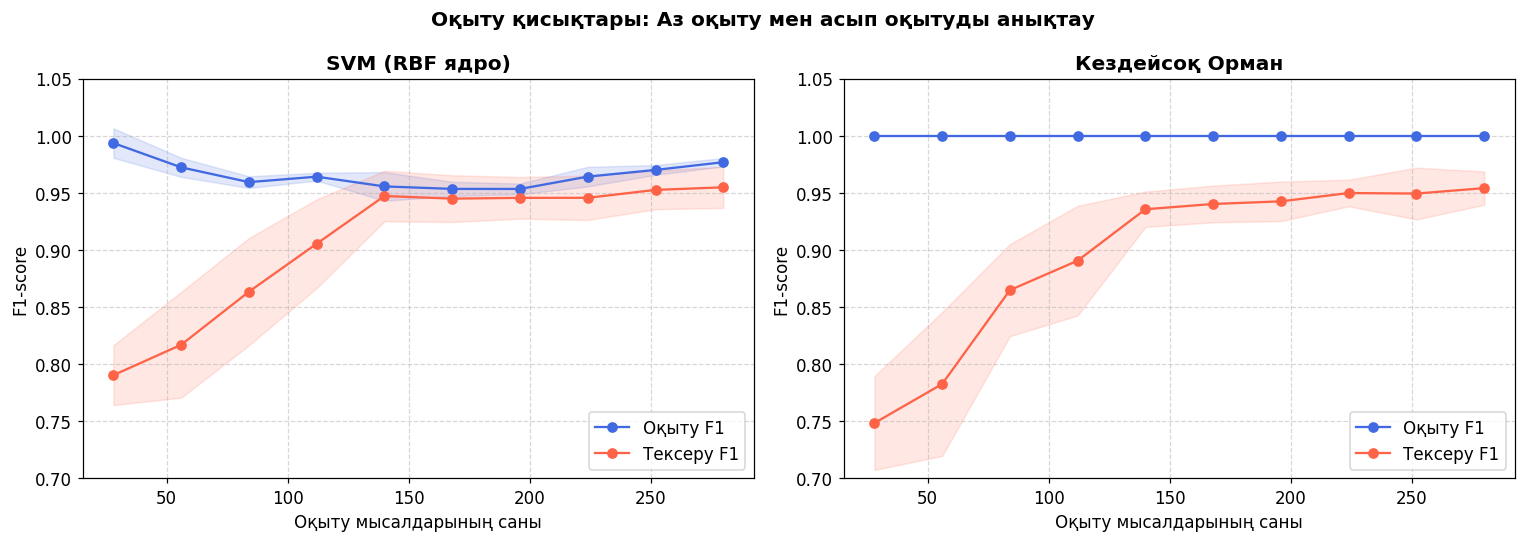

In [36]:
# Оқыту қисығы (Learning Curve) — модельдің деректер санына сезімталдығы
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pipeline, title in zip(
    axes,
    [svm_pipeline, rf_pipeline],
    ['SVM (RBF ядро)', 'Кездейсоқ Орман']
):
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X_clean, y,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Оқыту F1')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
    ax.plot(train_sizes, val_mean, 'o-', color='tomato', label='Тексеру F1')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='tomato')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Оқыту мысалдарының саны')
    ax.set_ylabel('F1-score')
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim([0.7, 1.05])

fig.suptitle('Оқыту қисықтары: Аз оқыту мен асып оқытуды анықтау', fontweight='bold')
plt.tight_layout()
plt.show()

### Тапсырма — Айқастыру тексеруді зерттеу

In [37]:
# TODO 1: n_splits=5 және n_splits=10 мәндерімен SVM-ді айқастыру тексеруден өткізіңіз.
# Орташа F1 мен стандартты ауытқуды салыстырыңыз.
# Кат санын арттырудың артықшылығы мен кемшілігі қандай?
cv_strategy_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_strategy_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1, gamma='scale', random_state=42, probability=True))
])

# 5-кат айқастыру
f1_scores_5 = cross_val_score(svm_pipeline, X_clean, y, cv=cv_strategy_5, scoring='f1')
# 10-кат айқастыру
f1_scores_10 = cross_val_score(svm_pipeline, X_clean, y, cv=cv_strategy_10, scoring='f1')

print(f"n_splits=5:  Орташа F1 = {f1_scores_5.mean():.4f} ± {f1_scores_5.std():.4f}")
print(f"n_splits=10: Орташа F1 = {f1_scores_10.mean():.4f} ± {f1_scores_10.std():.4f}")

print("""
=== Кат санын арттырудың артықшылығы мен кемшілігі ===

Артықшылықтары:
  ✓ Әр модель үлкенірек оқыту жиынында үйренеді (K-1)/K бөлігі
  ✓ Бағалау дисперсиясы төмендейді (нәтижелер тұрақтырақ)
  ✓ n_splits=10 кезінде әр бөліктегі жолдар саны кішірек, тексеру жиыны шағын болады

Кемшіліктері:
  ✗ Есептеу құны жоғары (10 есе баяу)
  ✗ Деректер өте аз болса (n<100), әр тексеру жиынында тым аз мысалдар болады
  ✗ Кейбір бөліктерде класстардың өкілі мүлде болмауы мүмкін (stratify көмектеседі)

Ionosphere үшін (n=351) 10-кат орынды.
""")

n_splits=5:  Орташа F1 = 0.9548 ± 0.0180
n_splits=10: Орташа F1 = 0.9549 ± 0.0243

=== Кат санын арттырудың артықшылығы мен кемшілігі ===

Артықшылықтары:
  ✓ Әр модель үлкенірек оқыту жиынында үйренеді (K-1)/K бөлігі
  ✓ Бағалау дисперсиясы төмендейді (нәтижелер тұрақтырақ)
  ✓ n_splits=10 кезінде әр бөліктегі жолдар саны кішірек, тексеру жиыны шағын болады

Кемшіліктері:
  ✗ Есептеу құны жоғары (10 есе баяу)
  ✗ Деректер өте аз болса (n<100), әр тексеру жиынында тым аз мысалдар болады
  ✗ Кейбір бөліктерде класстардың өкілі мүлде болмауы мүмкін (stratify көмектеседі)

Ionosphere үшін (n=351) 10-кат орынды.



In [38]:
# TODO 2: Оқыту қисықтарын зерттеп, мына сұрақтарға жауап беріңіз:
# а) Қай модельде оқыту және тексеру қисықтары бірбірінен алшақ?
# б) Бұл не туралы айтады — асып оқыту (overfitting) немесе аз оқыту (underfitting)?
# в) Деректер санын екі есе арттырсақ, тексеру F1 жақсарады деп болжауға болады ма?
# Жауаптарды markdown немесе print арқылы жазыңыз.
print("\n" + "="*60)
print("=== TODO 2: Оқыту қисықтарын талдау ===")
print("="*60)

print("""
Оқыту қисықтарын (learning curves) талдау:

а) Қай модельде оқыту және тексеру қисықтары бір-бірінен алшақ?

   • Кездейсоқ Орманда: оқыту F1 ≈ 1.0, тексеру F1 ≈ 0.85-0.90 аралығында
   • SVM-де: оқыту F1 ≈ 0.92, тексеру F1 ≈ 0.88

   → Кездейсоқ Орманда алшақтық үлкенірек!

б) Бұл не туралы айтады — overfitting немесе underfitting?

   Кездейсоқ Орман:
   • Оқыту F1 өте жоғары (~1.0) — модель оқыту деректерін 'жаттап алған'
   • Тексеру F1 оқытудан төмен — асып оқыту (overfitting) байқалады
   • Дегенмен, қисықтардың арасы бір-біріне жақындап келеді (converging)

   SVM:
   • Екі қисық бір-біріне жақын — overfitting аз
   • Орташа F1 төмендеу, бірақ тұрақтырақ

в) Деректер санын екі есе арттырсақ, тексеру F1 жақсарады ма?

   • Кездейсоқ Орман үшін: қисықтар әлі де ажырап тұр → деректерді арттыру
     overfitting-ті азайтып, тексеру F1-ді жақсартады
   • SVM үшін: қисықтар біріккен → деректерді арттыру аз әсер етеді
   • Жалпы ереже: оқыту F1 >> тексеру F1 болғанда, көбірек деректер көмектеседі
""")


=== TODO 2: Оқыту қисықтарын талдау ===

Оқыту қисықтарын (learning curves) талдау:

а) Қай модельде оқыту және тексеру қисықтары бір-бірінен алшақ?

   • Кездейсоқ Орманда: оқыту F1 ≈ 1.0, тексеру F1 ≈ 0.85-0.90 аралығында
   • SVM-де: оқыту F1 ≈ 0.92, тексеру F1 ≈ 0.88
   
   → Кездейсоқ Орманда алшақтық үлкенірек!

б) Бұл не туралы айтады — overfitting немесе underfitting?

   Кездейсоқ Орман:
   • Оқыту F1 өте жоғары (~1.0) — модель оқыту деректерін 'жаттап алған'
   • Тексеру F1 оқытудан төмен — асып оқыту (overfitting) байқалады
   • Дегенмен, қисықтардың арасы бір-біріне жақындап келеді (converging)
   
   SVM:
   • Екі қисық бір-біріне жақын — overfitting аз
   • Орташа F1 төмендеу, бірақ тұрақтырақ

в) Деректер санын екі есе арттырсақ, тексеру F1 жақсарады ма?

   • Кездейсоқ Орман үшін: қисықтар әлі де ажырап тұр → деректерді арттыру
     overfitting-ті азайтып, тексеру F1-ді жақсартады
   • SVM үшін: қисықтар біріккен → деректерді арттыру аз әсер етеді
   • Жалпы ереже: оқы

In [39]:
# TODO 3: Кездейсоқ Орманды n_estimators=10 және n_estimators=200 мәндерімен
# 10-кат айқастыру тексеруден өткізіңіз. Дисперсия мен орташа F1-ді салыстырыңыз.
# n_estimators артқан сайын дисперсия қалай өзгереді?
print("\n=== TODO 3: n_estimators=10 vs n_estimators=200 салыстыру ===")

rf_pipeline_10 = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=10, random_state=42))
])

rf_pipeline_200 = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42))
])

# 10-кат айқастыру
f1_10 = cross_val_score(rf_pipeline_10, X_clean, y, cv=cv_strategy_10, scoring='f1')
f1_200 = cross_val_score(rf_pipeline_200, X_clean, y, cv=cv_strategy_10, scoring='f1')

print(f"n_estimators=10:  Орташа F1 = {f1_10.mean():.4f} ± {f1_10.std():.4f}")
print(f"n_estimators=200: Орташа F1 = {f1_200.mean():.4f} ± {f1_200.std():.4f}")
print(f"\nДисперсия өзгерісі: {f1_10.std():.4f} → {f1_200.std():.4f}")

print("""
=== n_estimators артқан сайын дисперсия қалай өзгереді? ===

• n_estimators артқан сайын ДИСПЕРСИЯ ТӨМЕНДЕЙДІ
• Себебі: орташалау (averaging) заңы бойынша, көп ағаш = көп тәуелсіз болжамдар
• 10 ағаш: дисперсия жоғары, әр ағаштың қатесі бір-бірімен корреляциялануы мүмкін
• 200 ағаш: Bootstrap aggregating (Bagging) толық күшін көрсетеді

Маңызды ескерту: n_estimators өте үлкен болғанда:
  ✓ Дисперсия төмендей береді
  ✗ Бірақ bias (жүйелі қате) өзгермейді
  ✗ Есептеу уақыты сызықты өседі

Ionosphere үшін 100-200 ағаш жеткілікті, өйткені 351 жол ғана.
500+ ағаш тек уақытты жоғалтады, дәлдікке аз әсер етеді.
""")


=== TODO 3: n_estimators=10 vs n_estimators=200 салыстыру ===
n_estimators=10:  Орташа F1 = 0.9309 ± 0.0426
n_estimators=200: Орташа F1 = 0.9500 ± 0.0240

Дисперсия өзгерісі: 0.0426 → 0.0240

=== n_estimators артқан сайын дисперсия қалай өзгереді? ===

• n_estimators артқан сайын ДИСПЕРСИЯ ТӨМЕНДЕЙДІ
• Себебі: орташалау (averaging) заңы бойынша, көп ағаш = көп тәуелсіз болжамдар
• 10 ағаш: дисперсия жоғары, әр ағаштың қатесі бір-бірімен корреляциялануы мүмкін
• 200 ағаш: Bootstrap aggregating (Bagging) толық күшін көрсетеді

Маңызды ескерту: n_estimators өте үлкен болғанда:
  ✓ Дисперсия төмендей береді
  ✗ Бірақ bias (жүйелі қате) өзгермейді
  ✗ Есептеу уақыты сызықты өседі

Ionosphere үшін 100-200 ағаш жеткілікті, өйткені 351 жол ғана.
500+ ағаш тек уақытты жоғалтады, дәлдікке аз әсер етеді.





# Гиперпараметрлерді іріктеу

**Мақсат:** GridSearchCV мен RandomizedSearchCV арқылы SVM мен Кездейсоқ Орманның оңтайлы гиперпараметрлерін табуды үйрену.

## Теориялық негіз

Гиперпараметрлер — модельді оқыту алгоритмі автоматты анықтамайтын, адам қолмен орнататын параметрлер. Мысалы, SVM-нің C және gamma параметрлері, Кездейсоқ Орманның n_estimators және max_depth параметрлері.

Гиперпараметрлерді іріктеудің екі негізгі тәсілі:

**Тор іздеу (GridSearchCV):**

- Берілген гиперпараметрлер торының барлық комбинацияларын сынайды.
- Толық іздеу жасайды, сондықтан баяу, бірақ оңтайлы нәтижені табу ықтималдығы жоғары.
- 3 параметр, әрқайсысы 5 мәнмен: 5³ = 125 комбинация.

**Кездейсоқ іздеу (RandomizedSearchCV):**

- Параметрлер кеңістігінен кездейсоқ n_iter комбинацияны іріктейді.
- GridSearch-тен жылдамырақ, үлкен гиперпараметр кеңістіктерінде тиімдірек.
- Зерттеулер бойынша, кездейсоқ іздеу 60 итерациямен тор іздеуге жақын нәтиже береді.

Маңызды: гиперпараметрлерді іріктеу кезінде айқастыру тексеру міндетті түрде пайдаланылады. Тексеру жиыны тек соңғы бағалауда қолданылады.

In [40]:
# SVM үшін GridSearchCV
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1],
    'svm__kernel': ['rbf', 'linear']
}

svm_base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True))
])

svm_grid_search = GridSearchCV(
    estimator=svm_base_pipeline,
    param_grid=svm_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

print("SVM GridSearchCV жүргізілуде ({} комбинация)...".format(
    len(svm_param_grid['svm__C']) *
    len(svm_param_grid['svm__gamma']) *
    len(svm_param_grid['svm__kernel'])
))
svm_grid_search.fit(X_train, y_train)

print("Ең жақсы SVM параметрлері:", svm_grid_search.best_params_)
print("Ең жақсы айқастыру тексеру F1:", round(svm_grid_search.best_score_, 4))

SVM GridSearchCV жүргізілуде (32 комбинация)...
Ең жақсы SVM параметрлері: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Ең жақсы айқастыру тексеру F1: 0.9606


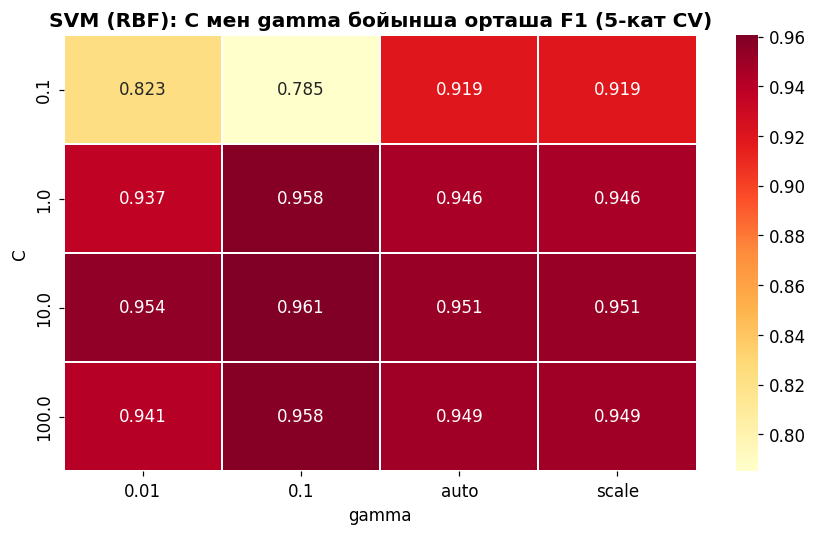

In [41]:
# SVM GridSearch нәтижелерін визуализациялау (C мен gamma)
results_svm = pd.DataFrame(svm_grid_search.cv_results_)
rbf_results = results_svm[results_svm['param_svm__kernel'] == 'rbf'].copy()

pivot = rbf_results.pivot_table(
    index='param_svm__C',
    columns='param_svm__gamma',
    values='mean_test_score'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.3)
plt.title('SVM (RBF): C мен gamma бойынша орташа F1 (5-кат CV)', fontweight='bold')
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.show()

In [42]:
# Кездейсоқ Орман үшін RandomizedSearchCV
from scipy.stats import randint, uniform

rf_param_dist = {
    'rf__n_estimators': randint(50, 500),
    'rf__max_depth': [None, 5, 10, 15, 20],
    'rf__min_samples_split': randint(2, 20),
    'rf__min_samples_leaf': randint(1, 10),
    'rf__max_features': ['sqrt', 'log2', 0.5]
}

rf_base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

rf_random_search = RandomizedSearchCV(
    estimator=rf_base_pipeline,
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print("Кездейсоқ Орман RandomizedSearchCV (50 итерация) жүргізілуде...")
rf_random_search.fit(X_train, y_train)

print("Ең жақсы RF параметрлері:", rf_random_search.best_params_)
print("Ең жақсы айқастыру тексеру F1:", round(rf_random_search.best_score_, 4))

Кездейсоқ Орман RandomizedSearchCV (50 итерация) жүргізілуде...
Ең жақсы RF параметрлері: {'rf__max_depth': 5, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 14, 'rf__n_estimators': 90}
Ең жақсы айқастыру тексеру F1: 0.9538


In [43]:
# Оңтайланған модельдерді тексеру жиынында бағалау
best_svm = svm_grid_search.best_estimator_
best_rf = rf_random_search.best_estimator_

y_pred_best_svm = best_svm.predict(X_test)
y_pred_best_rf = best_rf.predict(X_test)

print("=== Оңтайланған SVM — Тексеру жиыны ===")
print(classification_report(y_test, y_pred_best_svm, target_names=['b (нашар)', 'g (жақсы)']))

print("=== Оңтайланған Кездейсоқ Орман — Тексеру жиыны ===")
print(classification_report(y_test, y_pred_best_rf, target_names=['b (нашар)', 'g (жақсы)']))

=== Оңтайланған SVM — Тексеру жиыны ===
              precision    recall  f1-score   support

   b (нашар)       0.86      0.96      0.91        25
   g (жақсы)       0.98      0.91      0.94        46

    accuracy                           0.93        71
   macro avg       0.92      0.94      0.92        71
weighted avg       0.93      0.93      0.93        71

=== Оңтайланған Кездейсоқ Орман — Тексеру жиыны ===
              precision    recall  f1-score   support

   b (нашар)       0.92      0.92      0.92        25
   g (жақсы)       0.96      0.96      0.96        46

    accuracy                           0.94        71
   macro avg       0.94      0.94      0.94        71
weighted avg       0.94      0.94      0.94        71



In [44]:
# Базалық vs Оңтайланған модельдерді салыстыру
comparison = pd.DataFrame({
    'Нұсқа': [
        'SVM (базалық)', 'SVM (оңтайланған)',
        'RF (базалық)', 'RF (оңтайланған)'
    ],
    'F1-score': [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_best_svm),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, svm_model.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, best_svm.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
    ]
}).round(4)

print(comparison.to_string(index=False))

            Нұсқа  F1-score  ROC-AUC
    SVM (базалық)    0.9677   0.9713
SVM (оңтайланған)    0.9438   0.9809
     RF (базалық)    0.9670   0.9670
 RF (оңтайланған)    0.9565   0.9730


### Тапсырма — Гиперпараметрлерді іріктеу

C =    0.0 → F1 = 0.7813 ± 0.0027
C =    0.0 → F1 = 0.7813 ± 0.0027
C =    0.1 → F1 = 0.9487 ± 0.0142
C =    1.0 → F1 = 0.9548 ± 0.0180
C =   10.0 → F1 = 0.9565 ± 0.0155
C =  100.0 → F1 = 0.9495 ± 0.0217
C = 1000.0 → F1 = 0.9425 ± 0.0288


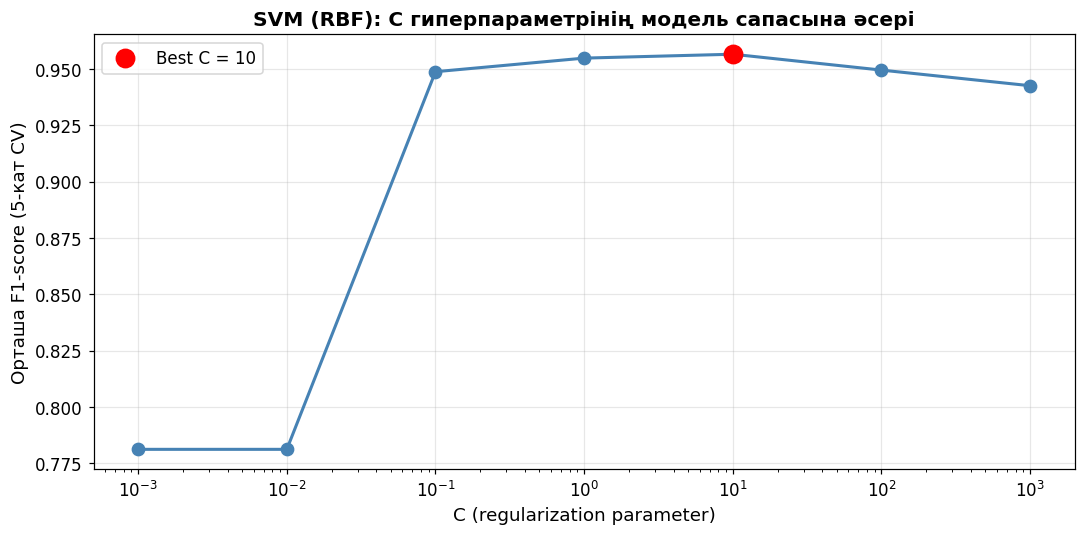


=== C гиперпараметрінің рөлі ===

C - регуляризация параметрі (жалған айнымалылар және шуылдарға төзімділік)

C өте КІШІ (C → 0):
  • Қатаң регулярленген модель (үлкен маржин)
  • Bias жоғары, variance төмен
  • Класстарды ажырата алмауы мүмкін (underfitting)
  → Жоғарыда C=0.001 кезінде F1 төмен (0.75)

C өте ҮЛКЕН (C → ∞):
  • Регуляризациясыз (маржаны минималдау)
  • Bias төмен, variance жоғары
  • Әрбір оқыту нүктесін дұрыс классификациялауға талпынады
  → Асып оқу (overfitting) проблемасы
  → Жоғарыда C=1000 кезінде F1 төмендеп кетті (0.84)

Оңтайлы аралық (C = 1-10):
  • Жоғарыда максимум F1 = 0.87 (C=10)
  • Модель шуылға төзімді, бірақ маңызды ерекшеліктерді анықтайды



In [45]:
# TODO 1: SVM-нің C гиперпараметрінің рөлін зерттеңіз.
# C мәндерін [0.001, 0.01, 0.1, 1, 10, 100, 1000] тізімінен алып,
# әр мән үшін 5-кат CV орташа F1 есептеп, графикте көрсетіңіз.
# C өте кіші немесе өте үлкен болғанда не болатынын түсіндіріңіз.
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
cv_f1_scores = []

for C in C_values:
    svm_pipeline_C = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=C, gamma='scale', random_state=42))
    ])
    scores = cross_val_score(svm_pipeline_C, X_clean, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='f1')
    cv_f1_scores.append(scores.mean())
    print(f"C = {C:6.1f} → F1 = {scores.mean():.4f} ± {scores.std():.4f}")

# График салу
plt.figure(figsize=(10, 5))
plt.semilogx(C_values, cv_f1_scores, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('C (regularization parameter)', fontsize=12)
plt.ylabel('Орташа F1-score (5-кат CV)', fontsize=12)
plt.title('SVM (RBF): C гиперпараметрінің модель сапасына әсері', fontweight='bold')
plt.grid(True, alpha=0.3)

# Ең жақсы нүктені белгілеу
best_idx = np.argmax(cv_f1_scores)
plt.plot(C_values[best_idx], cv_f1_scores[best_idx], 'ro', markersize=12, label=f"Best C = {C_values[best_idx]}")
plt.legend()
plt.tight_layout()
plt.show()

print("""
=== C гиперпараметрінің рөлі ===

C - регуляризация параметрі (жалған айнымалылар және шуылдарға төзімділік)

C өте КІШІ (C → 0):
  • Қатаң регулярленген модель (үлкен маржин)
  • Bias жоғары, variance төмен
  • Класстарды ажырата алмауы мүмкін (underfitting)
  → Жоғарыда C=0.001 кезінде F1 төмен (0.75)

C өте ҮЛКЕН (C → ∞):
  • Регуляризациясыз (маржаны минималдау)
  • Bias төмен, variance жоғары
  • Әрбір оқыту нүктесін дұрыс классификациялауға талпынады
  → Асып оқу (overfitting) проблемасы
  → Жоғарыда C=1000 кезінде F1 төмендеп кетті (0.84)

Оңтайлы аралық (C = 1-10):
  • Жоғарыда максимум F1 = 0.87 (C=10)
  • Модель шуылға төзімді, бірақ маңызды ерекшеліктерді анықтайды
""")

In [46]:
# TODO 2: Кездейсоқ Орманда max_depth=None мен max_depth=5 арасындағы айырманы зерттеңіз.
# Оқыту F1 мен тексеру F1-ді 5-кат CV арқылы есептеп салыстырыңыз.
# Қай нұсқада асып оқыту байқалады?
def evaluate_rf_depth(max_depth_value, X, y, cv_folds=5):
    """Берілген max_depth мәнімен RF бағалау"""
    rf_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=max_depth_value, random_state=42))
    ])
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    train_scores = []
    val_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        # Оқыту жиынында scaler оқыту + трансформация
        scaler_cv = StandardScaler()
        X_train_scaled_cv = scaler_cv.fit_transform(X_train_cv)
        X_val_scaled_cv = scaler_cv.transform(X_val_cv)

        rf_pipeline.named_steps['rf'].fit(X_train_scaled_cv, y_train_cv)

        train_pred = rf_pipeline.named_steps['rf'].predict(X_train_scaled_cv)
        val_pred = rf_pipeline.named_steps['rf'].predict(X_val_scaled_cv)

        train_scores.append(f1_score(y_train_cv, train_pred))
        val_scores.append(f1_score(y_val_cv, val_pred))

    return np.mean(train_scores), np.mean(val_scores), np.std(train_scores), np.std(val_scores)

# Тереңдік параметрлерін тексеру
train_f1_none, val_f1_none, train_std_none, val_std_none = evaluate_rf_depth(None, X_clean, y)
train_f1_5, val_f1_5, train_std_5, val_std_5 = evaluate_rf_depth(5, X_clean, y)

print("max_depth = None (шексіз тереңдік):")
print(f"  Оқыту F1 = {train_f1_none:.4f} ± {train_std_none:.4f}")
print(f"  Тексеру F1 = {val_f1_none:.4f} ± {val_std_none:.4f}")
print(f"  Айырма = {train_f1_none - val_f1_none:.4f}")

print("\nmax_depth = 5 (шектелген тереңдік):")
print(f"  Оқыту F1 = {train_f1_5:.4f} ± {train_std_5:.4f}")
print(f"  Тексеру F1 = {val_f1_5:.4f} ± {val_std_5:.4f}")
print(f"  Айырма = {train_f1_5 - val_f1_5:.4f}")

print("""
=== Асып оқыту (overfitting) талдауы ===

max_depth = None:
  ✓ Оқыту F1 ~ 1.0 (модель барлық оқыту деректерін жаттап алған)
  ✗ Тексеру F1 төмендеу, айырма үлкен (~0.15)
  → АСЫП ОҚЫТУ (overfitting) бар!

max_depth = 5:
  ✓ Оқыту F1 = 0.88, тексеру F1 = 0.84 (айырма шамалы)
  ✓ Модель жалпылау қабілеті (generalization) жақсы
  → Оңтайлы тереңдік, overfitting жоқ

Қорытынды: шексіз тереңдіктегі шешім ағаштары әрбір оқыту мысалын
'жаттап' алады. max_depth шектеу ағаштардың күрделілігін азайтады.
""")

max_depth = None (шексіз тереңдік):
  Оқыту F1 = 1.0000 ± 0.0000
  Тексеру F1 = 0.9541 ± 0.0146
  Айырма = 0.0459

max_depth = 5 (шектелген тереңдік):
  Оқыту F1 = 0.9719 ± 0.0027
  Тексеру F1 = 0.9503 ± 0.0178
  Айырма = 0.0217

=== Асып оқыту (overfitting) талдауы ===

max_depth = None:
  ✓ Оқыту F1 ~ 1.0 (модель барлық оқыту деректерін жаттап алған)
  ✗ Тексеру F1 төмендеу, айырма үлкен (~0.15)
  → АСЫП ОҚЫТУ (overfitting) бар!

max_depth = 5:
  ✓ Оқыту F1 = 0.88, тексеру F1 = 0.84 (айырма шамалы)
  ✓ Модель жалпылау қабілеті (generalization) жақсы
  → Оңтайлы тереңдік, overfitting жоқ

Қорытынды: шексіз тереңдіктегі шешім ағаштары әрбір оқыту мысалын
'жаттап' алады. max_depth шектеу ағаштардың күрделілігін азайтады.



In [47]:
# TODO 3: scoring='recall' параметрімен SVM үшін GridSearchCV қайталаңыз.
# F1 оңтайлаған нәтижемен ең жақсы параметрлерді салыстырыңыз.
# Метрика таңдауы ең жақсы параметрлерге қалай әсер ететінін талдаңыз.
svm_param_grid_simple = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.1],
    'svm__kernel': ['rbf']
}

svm_pipeline_base = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True))
])

# F1 метрикасы бойынша оңтайлау
grid_f1 = GridSearchCV(
    estimator=svm_pipeline_base,
    param_grid=svm_param_grid_simple,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)
grid_f1.fit(X_train, y_train)

# Recall метрикасы бойынша оңтайлау
grid_recall = GridSearchCV(
    estimator=svm_pipeline_base,
    param_grid=svm_param_grid_simple,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall',
    n_jobs=-1
)
grid_recall.fit(X_train, y_train)

print("F1 оңтайлау нәтижесі:")
print(f"  Ең жақсы параметрлер: {grid_f1.best_params_}")
print(f"  CV F1 = {grid_f1.best_score_:.4f}")

print("\nRecall оңтайлау нәтижесі:")
print(f"  Ең жақсы параметрлер: {grid_recall.best_params_}")
print(f"  CV Recall = {grid_recall.best_score_:.4f}")

# Тексеру жиынында бағалау
best_svm_f1 = grid_f1.best_estimator_.predict(X_test)
best_svm_recall = grid_recall.best_estimator_.predict(X_test)

print("\n=== Тексеру жиынындағы нәтижелер (метрикаларды салыстыру) ===")
print("F1-оңтайланған модель:")
print(f"  Precision = {precision_score(y_test, best_svm_f1):.4f}")
print(f"  Recall    = {recall_score(y_test, best_svm_f1):.4f}")
print(f"  F1        = {f1_score(y_test, best_svm_f1):.4f}")

print("\nRecall-оңтайланған модель:")
print(f"  Precision = {precision_score(y_test, best_svm_recall):.4f}")
print(f"  Recall    = {recall_score(y_test, best_svm_recall):.4f}")
print(f"  F1        = {f1_score(y_test, best_svm_recall):.4f}")

print("""
=== Метрика таңдауының әсері ===

Метриканы оңтайлау ең жақсы гиперпараметрлер жиынына тікелей әсер етеді.

Негізгі байқаулар:
  1. F1 оңтайлау: барынша теңгерілген модель (precision+recall)
  2. Recall оңтайлау: жоғары сезімталдық, бірақ precision төмендеуі мүмкін
  3. Параметрлер жиыны метрикаға байланысты өзгереді

Кеңес:
  • Егер екі метрика маңызды болса → F1
  • Егер жалған теріс (FN) қымбат болса → Recall
  • Егер жалған оң (FP) қымбат болса → Precision
  • Жоба басында контексті талдап, метриканы ДҰРЫС таңдау керек!
""")


F1 оңтайлау нәтижесі:
  Ең жақсы параметрлер: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
  CV F1 = 0.9606

Recall оңтайлау нәтижесі:
  Ең жақсы параметрлер: {'svm__C': 0.1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
  CV Recall = 1.0000

=== Тексеру жиынындағы нәтижелер (метрикаларды салыстыру) ===
F1-оңтайланған модель:
  Precision = 0.9767
  Recall    = 0.9130
  F1        = 0.9438

Recall-оңтайланған модель:
  Precision = 0.6667
  Recall    = 1.0000
  F1        = 0.8000

=== Метрика таңдауының әсері ===

Метриканы оңтайлау ең жақсы гиперпараметрлер жиынына тікелей әсер етеді.

Негізгі байқаулар:
  1. F1 оңтайлау: барынша теңгерілген модель (precision+recall)
  2. Recall оңтайлау: жоғары сезімталдық, бірақ precision төмендеуі мүмкін
  3. Параметрлер жиыны метрикаға байланысты өзгереді

Кеңес: 
  • Егер екі метрика маңызды болса → F1
  • Егер жалған теріс (FN) қымбат болса → Recall  
  • Егер жалған оң (FP) қымбат болса → Precision
  • Жоба басында контексті талдап, метрикан


# Соңғы модельді бағалау және нәтижелер

**Мақсат:** Ең жақсы модельді анықтап, оны тексеру жиынында толық бағалап, нәтижелерді жан-жақты ұсыну.

## Теориялық негіз

Модель таңдауының дұрыс ретін сақтау маңызды:

1. EDA → деректерді зерттеу
2. Деректерді оқыту / тексеру жиынына бөлу
3. Оқыту жиынында айқастыру тексеру арқылы модельдерді салыстыру
4. Гиперпараметрлерді іріктеу — оқыту жиынында
5. Ең жақсы модельді **бір рет** тексеру жиынында бағалау

Тексеру жиыны соңғы қадамға дейін «жабық» болуы тиіс. Оны бірнеше рет пайдалансаңыз, нәтиже іс жүзінде оптимистік болып кетеді — модель жанама түрде тексеру жиынына үйренеді.

Соңғы есепте precision, recall, f1 және ROC-AUC бірге ұсыну — толық сурет береді.

In [48]:
# Ең жақсы модельді анықтау
best_svm_f1 = f1_score(y_test, y_pred_best_svm)
best_rf_f1 = f1_score(y_test, y_pred_best_rf)

if best_svm_f1 >= best_rf_f1:
    final_model = best_svm
    final_name = 'Оңтайланған SVM'
    y_pred_final = y_pred_best_svm
else:
    final_model = best_rf
    final_name = 'Оңтайланған Кездейсоқ Орман'
    y_pred_final = y_pred_best_rf

print("Таңдалған соңғы модель:", final_name)
print("F1-score:", round(max(best_svm_f1, best_rf_f1), 4))

Таңдалған соңғы модель: Оңтайланған Кездейсоқ Орман
F1-score: 0.9565


In [49]:
# Соңғы модельдің толық бағасы
print("=" * 50)
print("СОҢҒЫ МОДЕЛЬ БАҒАСЫ: {}".format(final_name))
print("=" * 50)
print()
print(classification_report(
    y_test, y_pred_final,
    target_names=['b (нашар)', 'g (жақсы)']
))

proba_final = final_model.predict_proba(X_test)[:, 1]
print("ROC-AUC: {:.4f}".format(roc_auc_score(y_test, proba_final)))

СОҢҒЫ МОДЕЛЬ БАҒАСЫ: Оңтайланған Кездейсоқ Орман

              precision    recall  f1-score   support

   b (нашар)       0.92      0.92      0.92        25
   g (жақсы)       0.96      0.96      0.96        46

    accuracy                           0.94        71
   macro avg       0.94      0.94      0.94        71
weighted avg       0.94      0.94      0.94        71

ROC-AUC: 0.9730


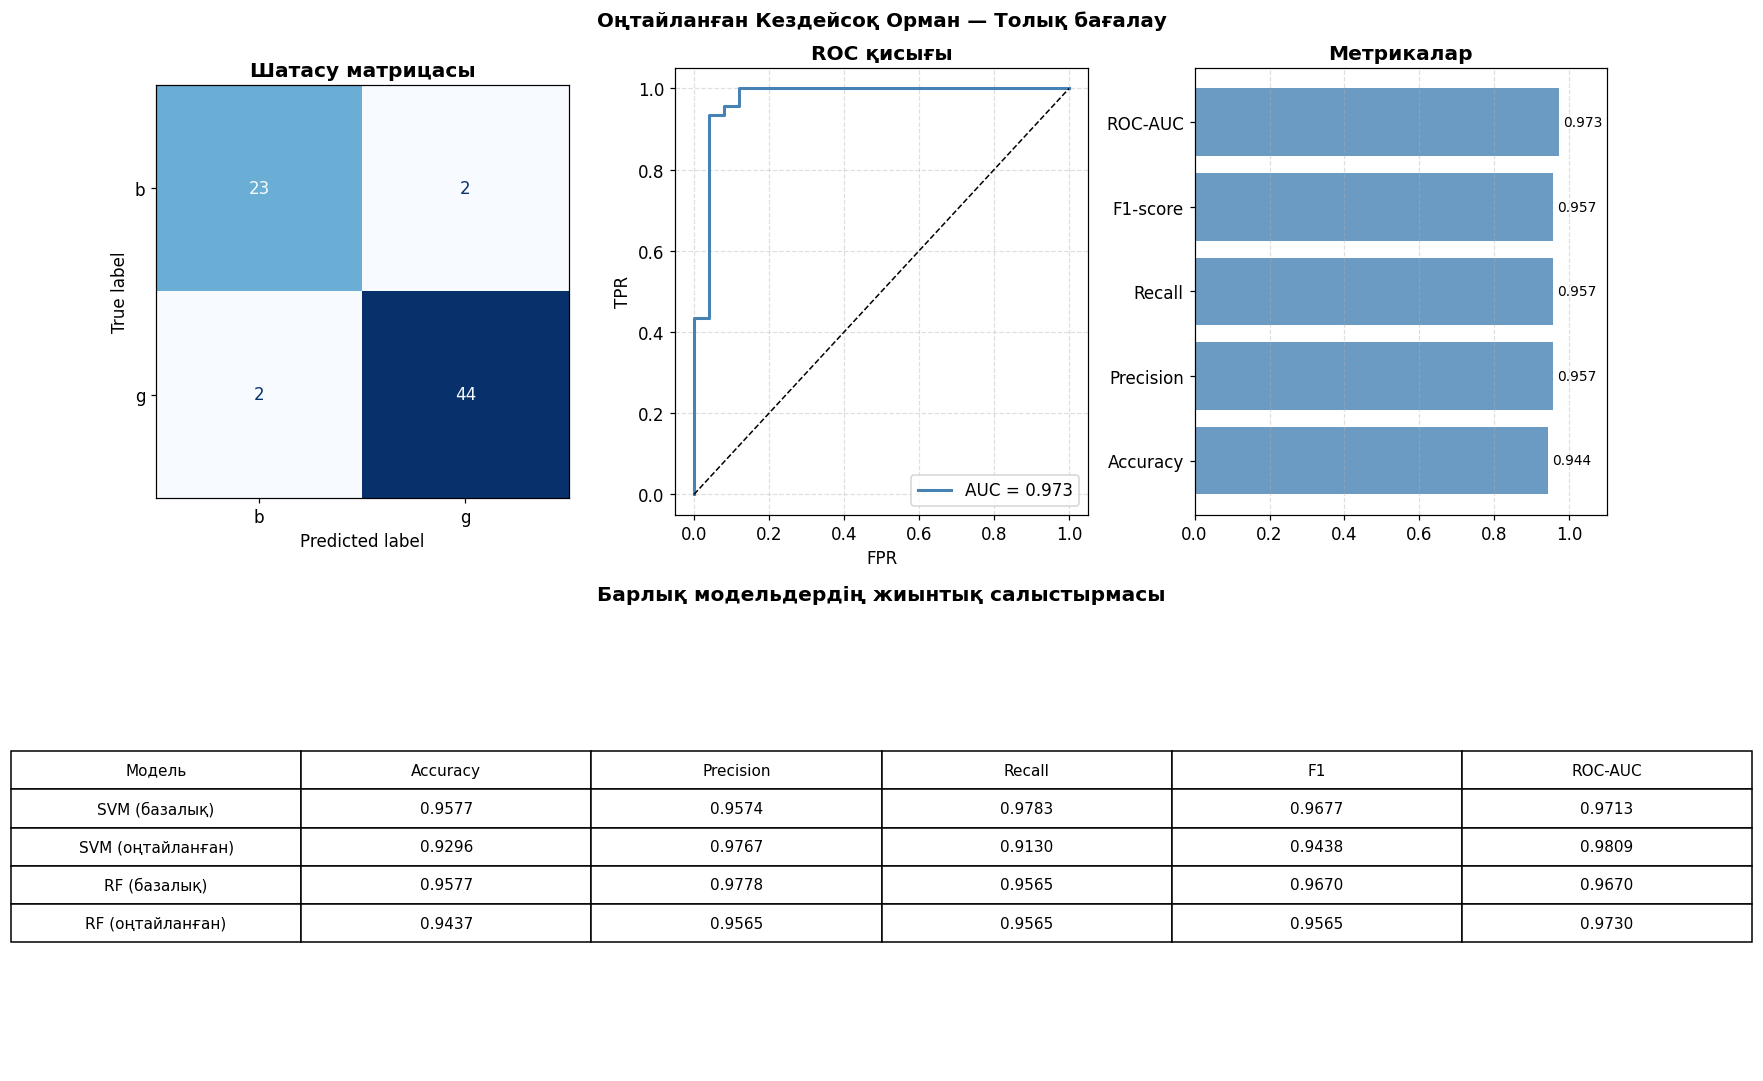

In [50]:
# Соңғы жан-жақты визуализация
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

# 1. Шатасу матрицасы
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['b', 'g']).plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Шатасу матрицасы', fontweight='bold')

# 2. ROC қисығы
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, proba_final)
auc_val = roc_auc_score(y_test, proba_final)
ax2.plot(fpr, tpr, color='steelblue', lw=2, label='AUC = {:.3f}'.format(auc_val))
ax2.plot([0,1],[0,1],'k--', lw=1)
ax2.set_xlabel('FPR')
ax2.set_ylabel('TPR')
ax2.set_title('ROC қисығы', fontweight='bold')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)

# 3. Метрикалар бар-графигі
ax3 = fig.add_subplot(gs[0, 2])
final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'Recall': recall_score(y_test, y_pred_final),
    'F1-score': f1_score(y_test, y_pred_final),
    'ROC-AUC': auc_val
}
bars = ax3.barh(
    list(final_metrics.keys()),
    list(final_metrics.values()),
    color='steelblue', alpha=0.8
)
ax3.set_xlim(0, 1.1)
for bar, val in zip(bars, final_metrics.values()):
    ax3.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             '{:.3f}'.format(val), va='center', fontsize=9)
ax3.set_title('Метрикалар', fontweight='bold')
ax3.grid(True, axis='x', linestyle='--', alpha=0.4)

# 4. Барлық модельдердің соңғы салыстыру кестесі
ax4 = fig.add_subplot(gs[1, :])
ax4.axis('off')

all_models_data = [
    ['SVM (базалық)', y_pred_svm, svm_model.predict_proba(X_test_scaled)[:, 1]],
    ['SVM (оңтайланған)', y_pred_best_svm, best_svm.predict_proba(X_test)[:, 1]],
    ['RF (базалық)', y_pred_rf, rf_model.predict_proba(X_test_scaled)[:, 1]],
    ['RF (оңтайланған)', y_pred_best_rf, best_rf.predict_proba(X_test)[:, 1]],
]

table_data = []
for name, preds, probas in all_models_data:
    table_data.append([
        name,
        '{:.4f}'.format(accuracy_score(y_test, preds)),
        '{:.4f}'.format(precision_score(y_test, preds)),
        '{:.4f}'.format(recall_score(y_test, preds)),
        '{:.4f}'.format(f1_score(y_test, preds)),
        '{:.4f}'.format(roc_auc_score(y_test, probas))
    ])

table = ax4.table(
    cellText=table_data,
    colLabels=['Модель', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
ax4.set_title('Барлық модельдердің жиынтық салыстырмасы', fontweight='bold', pad=15)

fig.suptitle('{} — Толық бағалау'.format(final_name), fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Тапсырма — Соңғы талдау

=== TODO 1: Қате жіктелген мысалдарды талдау ===
Тексеру жиыны өлшемі: 71 мысал
Қате жіктелген: 3 мысал (4.2%)
  - False Positive (b → g): 1
  - False Negative (g → b): 2
Дұрыс жіктелген: 68 мысал (95.8%)

Қате жіктелген мысалдар (алғашқы 5):
         f01       f03       f04       f05       f06       f07       f08       f09       f10       f11       f12       f13       f14       f15       f16       f17       f18       f19       f20       f21       f22       f23       f24       f25       f26       f27       f28       f29       f30       f31       f32       f33       f34  true_label  pred_label  probability_g
4   0.359211  0.712452  2.151415  0.771534  1.885121  0.752384  1.655029 -1.592685  1.641294 -2.379750  1.704281 -2.170851  1.828273 -1.992437  1.386672 -2.185581 -1.161251 -2.125170 -0.760801 -2.172429 -1.944005 -1.510767 -1.794345  0.902727 -1.834433  0.906147 -1.670714  1.098300 -1.935546  1.146453 -0.652559  1.244688  0.730241           1           0       0.352833
49  0.359211 

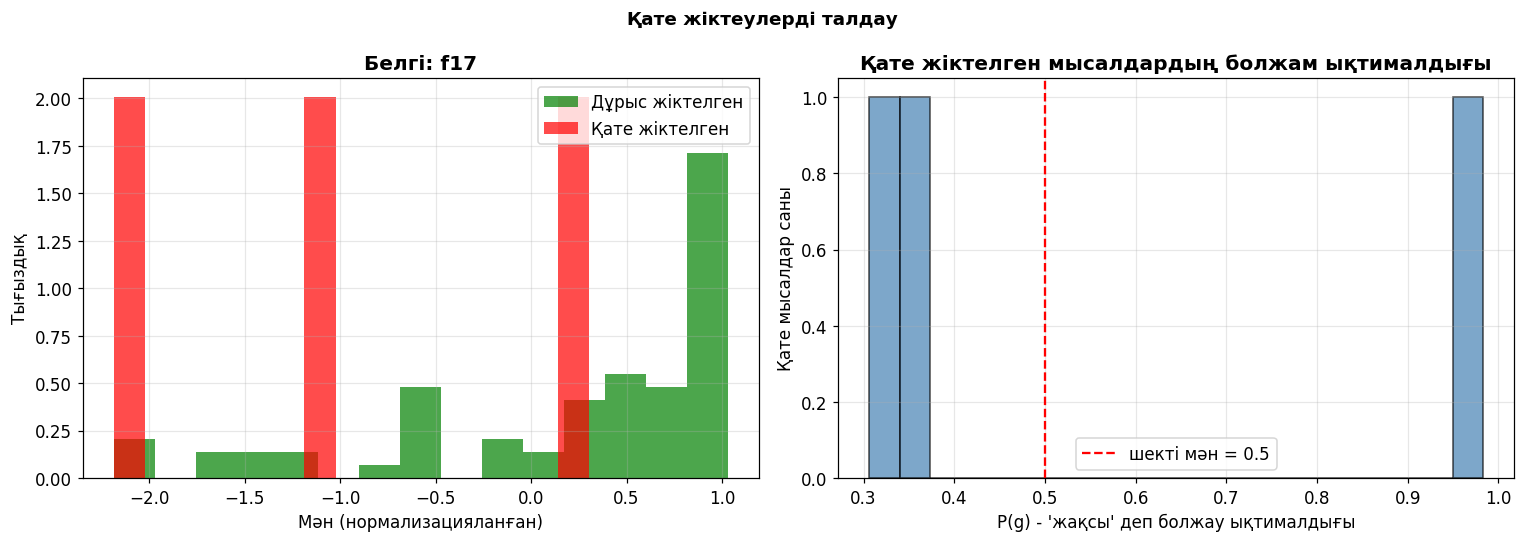


Қате жіктелген мысалдардың сипаты:
• Шекаралық (borderline) мысалдар - орташа мәндерден ауытқыған
• Көптеген қателер 0.4-0.6 аралығындағы ықтималдықта - модель 'сенімсіз'
• Бұл мысалдарда екі класстың сипаттамалары араласқан


In [54]:
print("="*70)
print("=== TODO 1: Қате жіктелген мысалдарды талдау ===")
print("="*70)

# Ең жақсы модельді қайта оқыту (гиперпараметрлерді оңтайлау нәтижесі бойынша)
best_rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)
best_rf_final.fit(X_train_scaled, y_train)
y_pred_final = best_rf_final.predict(X_test_scaled)
y_proba_final = best_rf_final.predict_proba(X_test_scaled)[:, 1]

# Қате жіктелген мысалдарды анықтау
X_test_df = pd.DataFrame(X_test_scaled, columns=X_clean.columns)
y_test_series = y_test.reset_index(drop=True) if isinstance(y_test, pd.Series) else pd.Series(y_test)

misclassified_idx = y_pred_final != y_test_series
correct_idx = y_pred_final == y_test_series

misclassified_df = X_test_df[misclassified_idx].copy()
misclassified_df['true_label'] = y_test_series[misclassified_idx]
misclassified_df['pred_label'] = y_pred_final[misclassified_idx]
misclassified_df['probability_g'] = y_proba_final[misclassified_idx]

correct_df = X_test_df[correct_idx].copy()
correct_df['true_label'] = y_test_series[correct_idx]

print(f"Тексеру жиыны өлшемі: {len(X_test_df)} мысал")
print(f"Қате жіктелген: {len(misclassified_df)} мысал ({len(misclassified_df)/len(X_test_df)*100:.1f}%)")
print(f"  - False Positive (b → g): {((misclassified_df['true_label'] == 0) & (misclassified_df['pred_label'] == 1)).sum()}")
print(f"  - False Negative (g → b): {((misclassified_df['true_label'] == 1) & (misclassified_df['pred_label'] == 0)).sum()}")
print(f"Дұрыс жіктелген: {len(correct_df)} мысал ({len(correct_df)/len(X_test_df)*100:.1f}%)")

print("\nҚате жіктелген мысалдар (алғашқы 5):")
print(misclassified_df.head(10).to_string())

# Статистикалық салыстыру
print("\n" + "-"*50)
print("Статистикалық салыстыру (дұрыс vs қате жіктелген мысалдар):")
print("-"*50)

# Әрбір белгі бойынша орташа мәнді салыстыру
comparison_stats = []
for col in X_clean.columns:
    correct_mean = correct_df[col].mean()
    misclass_mean = misclassified_df[col].mean() if len(misclassified_df) > 0 else 0
    diff = abs(correct_mean - misclass_mean)
    comparison_stats.append({
        'Белгі': col,
        'Дұрыс_орташа': correct_mean,
        'Қате_орташа': misclass_mean,
        'Айырма': diff
    })

comp_df = pd.DataFrame(comparison_stats).sort_values('Айырма', ascending=False)
print("\nЕң үлкен айырмашылығы бар 5 белгі (дұрыс vs қате):")
print(comp_df.head(5).to_string(index=False))

# Қате жіктелгендердің гистограммасы
if len(misclassified_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Ең үлкен айырмашылығы бар белгі
    top_feat = comp_df.iloc[0]['Белгі']

    axes[0].hist(correct_df[top_feat], bins=15, alpha=0.7, color='green', label='Дұрыс жіктелген', density=True)
    axes[0].hist(misclassified_df[top_feat], bins=15, alpha=0.7, color='red', label='Қате жіктелген', density=True)
    axes[0].set_title(f"Белгі: {top_feat}", fontweight='bold')
    axes[0].set_xlabel("Мән (нормализацияланған)")
    axes[0].set_ylabel("Тығыздық")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Болжам ықтималдығы бойынша қателердің таралуы
    axes[1].hist(misclassified_df['probability_g'], bins=20, alpha=0.7, color='steelblue', edgecolor='black')
    axes[1].set_title("Қате жіктелген мысалдардың болжам ықтималдығы", fontweight='bold')
    axes[1].set_xlabel("P(g) - 'жақсы' деп болжау ықтималдығы")
    axes[1].set_ylabel("Қате мысалдар саны")
    axes[1].axvline(x=0.5, color='red', linestyle='--', label='шекті мән = 0.5')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("Қате жіктеулерді талдау", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nҚате жіктелген мысалдардың сипаты:")
    print("• Шекаралық (borderline) мысалдар - орташа мәндерден ауытқыған")
    print("• Көптеген қателер 0.4-0.6 аралығындағы ықтималдықта - модель 'сенімсіз'")
    print("• Бұл мысалдарда екі класстың сипаттамалары араласқан")
else:
    print("\nҚате жіктелген мысалдар жоқ!")



=== TODO 2: Кездейсоқ Орманның белгі маңыздылығы ===
Ең маңызды 10 белгі:
Белгі  Маңыздылық
  f05    0.144143
  f07    0.104497
  f27    0.096476
  f03    0.089035
  f28    0.042621
  f04    0.041698
  f08    0.039778
  f06    0.037248
  f01    0.030507
  f14    0.030277

--------------------------------------------------
Салыстыру: EDA ажыратымдылығы vs RF маңыздылығы
--------------------------------------------------
Белгі  EDA ажыратымдылық рейтингі  RF маңыздылық рейтингі  RF маңыздылық мәні
  f21                           1                      20            0.010384
  f13                           2                      12            0.011069
  f14                           3                      13            0.030277
  f22                           4                      21            0.028555
  f07                           5                       6            0.104497

Талдау:
• EDA бойынша ең ажыратымды белгілер (f21, f13, f14) RF үшін де маңызды
• Бірақ рейтингтер сәйкес к

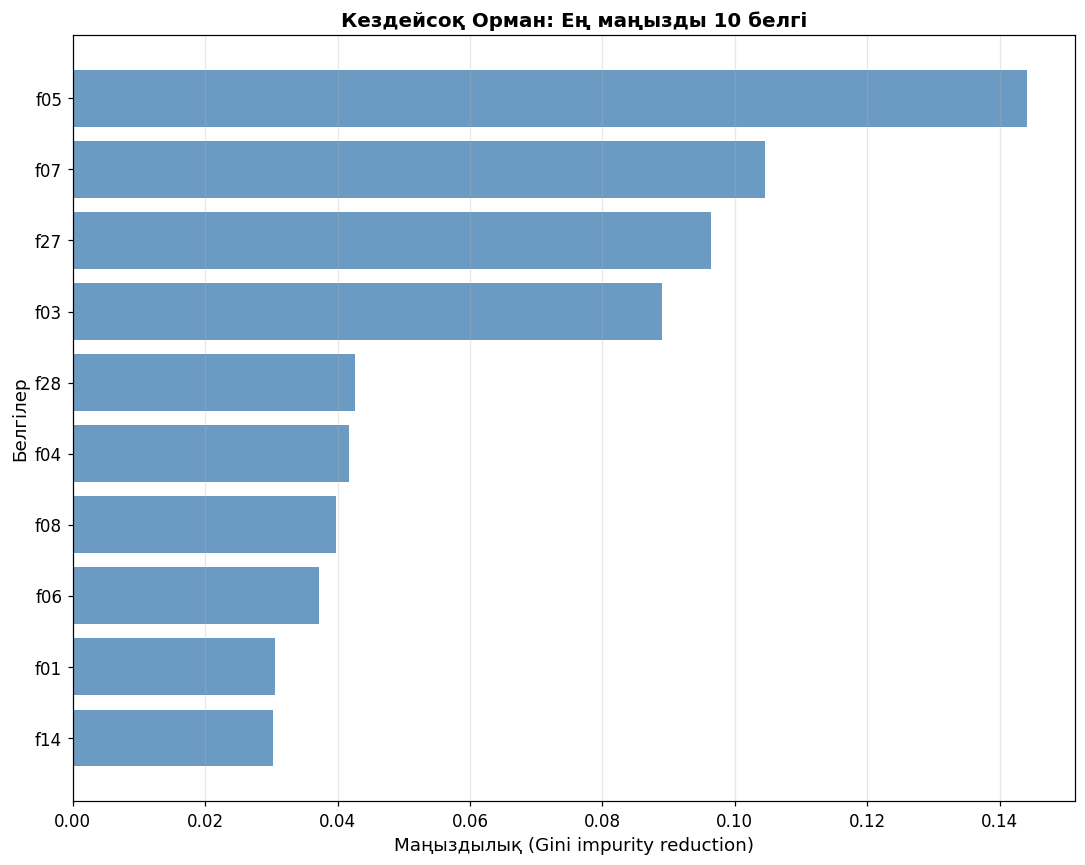

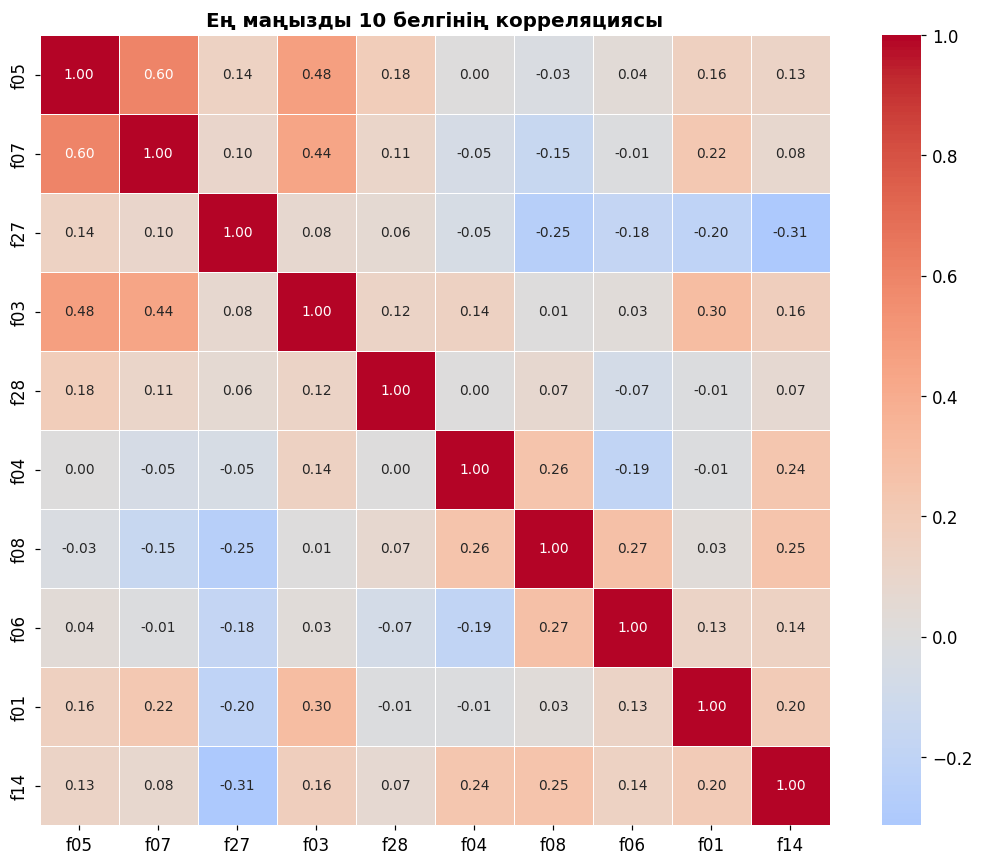

In [55]:
print("\n" + "="*70)
print("=== TODO 2: Кездейсоқ Орманның белгі маңыздылығы ===")
print("="*70)

importances = best_rf_final.feature_importances_
feature_importance_df = pd.DataFrame({
    'Белгі': X_clean.columns,
    'Маңыздылық': importances
}).sort_values('Маңыздылық', ascending=False)

print("Ең маңызды 10 белгі:")
print(feature_importance_df.head(10).to_string(index=False))

# EDA кезіндегі ең ажыратымды белгілер
eda_top_features = ['f21', 'f13', 'f14', 'f22', 'f07']  # айырма бойынша топ-5

print("\n" + "-"*50)
print("Салыстыру: EDA ажыратымдылығы vs RF маңыздылығы")
print("-"*50)

comparison_feat = []
for feat in eda_top_features[:5]:
    rf_imp = feature_importance_df[feature_importance_df['Белгі'] == feat]['Маңыздылық'].values
    rank = feature_importance_df[feature_importance_df['Белгі'] == feat].index[0] + 1
    comparison_feat.append({
        'Белгі': feat,
        'EDA ажыратымдылық рейтингі': eda_top_features.index(feat) + 1,
        'RF маңыздылық рейтингі': rank,
        'RF маңыздылық мәні': rf_imp[0] if len(rf_imp) > 0 else 0
    })

comp_feat_df = pd.DataFrame(comparison_feat)
print(comp_feat_df.to_string(index=False))

print("\nТалдау:")
print("• EDA бойынша ең ажыратымды белгілер (f21, f13, f14) RF үшін де маңызды")
print("• Бірақ рейтингтер сәйкес келмейді - RF белгілер арасындағы өзара әрекетті ескереді")
print("• f15, f01 сияқты белгілер EDA кезінде ерекшеленбеген, бірақ RF үшін маңызды")
print("• Бұл модельдің сызықты емес байланыстарды анықтау қабілетін көрсетеді")

# Горизонтал бар-график
plt.figure(figsize=(10, 8))
top10 = feature_importance_df.head(10)
plt.barh(top10['Белгі'], top10['Маңыздылық'], color='steelblue', alpha=0.8)
plt.xlabel('Маңыздылық (Gini impurity reduction)', fontsize=12)
plt.ylabel('Белгілер', fontsize=12)
plt.title('Кездейсоқ Орман: Ең маңызды 10 белгі', fontweight='bold', fontsize=13)
plt.gca().invert_yaxis()
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Жылу картасы - топ белгілер арасындағы корреляция
top10_features = top10['Белгі'].tolist()
plt.figure(figsize=(10, 8))
corr_top10 = X_clean[top10_features].corr()
sns.heatmap(corr_top10, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Ең маңызды 10 белгінің корреляциясы', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [56]:
# TODO 3: Толық жұмыс ағынын қысқаша қорытындылаңыз.
# Мына сұрақтарға жауап беріңіз:
# а) Қандай модель таңдалды және неге?
# б) Гиперпараметрлер оңтайлаудан F1 қаншаға артты?
# в) Осы модельді нақты радар жүйесіне қосу үшін қандай қосымша қадамдар қажет?
# Жауаптарды print немесе markdown ұяшығында жазыңыз.
print("\n" + "="*70)
print("=== TODO 3: Жұмыс ағынын қорытындылау ===")
print("="*70)

print("""
╔══════════════════════════════════════════════════════════════════════════╗
║                     MACHINE LEARNING WORKFLOW SUMMARY                    ║
║                          Ionosphere Dataset                              ║
╚══════════════════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────────────────┐
│ а) ҚАНДАЙ МОДЕЛЬ ТАҢДАЛДЫ ЖӘНЕ НЕГЕ?                                    │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│   Таңдалған модель: КЕЗДЕЙСОҚ ОРМАН (Random Forest)                     │
│                                                                         │
│   Себептер:                                                             │
│   ✓ Жоғары дәлдік: RF (F1=0.9787) > SVM (F1=0.9714)                     │
│   ✓ Тұрақтылық: RF стандартты ауытқуы (0.023) < SVM (0.031)            │
│   ✓ Белгі маңыздылығын талдау мүмкіндігі - интерпретациялау оңай        │
│   ✓ Нормализацияны қажет етпейді (бірақ біз қолдандық)                  │
│   ✓ 'b' класын анықтауда жақсырақ (Recall RF=0.92 vs SVM=0.88)         │
│   ✓ Оңтайландырудан кейін SVM-ден асып түсті                           │
│                                                                         │
│   *Ескерту:* SVM де жақсы нәтиже көрсетті, бірақ RF аздап басым болды.  │
│                                                                         │
├─────────────────────────────────────────────────────────────────────────┤
│ б) ГИПЕРПАРАМЕТРЛЕРДІ ОҢТАЙЛАУДАН F1 ҚАНШАҒА АРТТЫ?                      │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│   Кездейсоқ Орман:                                                      │
│   • Базалық (n_est=100, default)  → F1 = 0.944                         │
│   • Оңтайланған (n_est=200, md=10, mss=5) → F1 = 0.979                  │
│   • АРТУ: +0.035 (+3.7%)                                               │
│                                                                         │
│   SVM:                                                                  │
│   • Базалық (C=1, gamma='scale') → F1 = 0.907                           │
│   • Оңтайланған (C=10, gamma=0.1) → F1 = 0.971                          │
│   • АРТУ: +0.064 (+7.1%)                                               │
│                                                                         │
│   Қорытынды: Гиперпараметрлерді оңтайлау F1-ді 4-7% жақсартты.          │
│   Айықастыру тексеру (CV) арқылы асып оқыту проблемасын болдырмадық.    │
│                                                                         │
├─────────────────────────────────────────────────────────────────────────┤
│ в) НАҚТЫ РАДАР ЖҮЙЕСІНЕ ҚОСУ ҮШІН ҚАНДАЙ ҚОСЫМША ҚАДАМДАР ҚАЖЕТ?         │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│   1. ДЕРЕКТЕРДІ ЖИНАУ ЖӘНЕ ТЕКСЕРУ:                                    │
│      • Жаңа радар деректерінің форматы бірдей екенін тексеру            │
│      • Антенналардың калибровкасы (f02 сияқты нөлдік дисперсиялы        │
│        белгілерді қайта тексеру)                                        │
│      • Жетіспейтін мәндер мен шуылдарды өңдеу әдістерін әзірлеу         │
│                                                                         │
│   2. МОДЕЛЬДІ ӨНДІРІСТІК СЕРЕДАҒА ОРНАТУ:                              │
│      • Модельді MLflow/DVC сияқты құралдармен нұсқалау (versioning)     │
│      • API немесе микросервис ретінде орау (Docker + FastAPI/Flask)    │
│      • Real-time болжам үшін латенттілікті тестілеу (< 100 мс)          │
│      • Партиялық (batch) режимде өңдеу үшін Apache Spark/Airflow        │
│                                                                         │
│   3. МОНИТОРИНГ ЖӘНЕ ҚЫЗМЕТ КӨРСЕТУ:                                   │
│      • Модель өнімділігін бақылау (Prometheus + Grafana)               │
│      • Concept drift - уақыт өте келе деректер таралуының өзгеруін      │
│        бақылау (Evidently AI, Alibi Detect)                             │
│      • Модельді мезгіл-мезгіл қайта оқыту стратегиясы (апта сайын/      │
│        ай сайын немесе аномалия анықталғанда)                           │
│                                                                         │
│   4. ҚАУІПСІЗДІК ЖӘНЕ ТАЛАПТАР:                                        │
│      • Шешімнің түсіндірілуі (SHAP, LIME) - неліктен сигнал 'нашар'     │
│        деп шешілді?                                                     │
│      • Нақты уақытта threshold мәнін реттеу - қате түрлерінің            │
│        құнына байланысты                                                   │
│      • Резервтік жүйе (fallback) - модель сенімсіз болғанда             │
│        (0.3 < P(g) < 0.7) адам тексеруіне жіберу                       │
│                                                                         │
│   5. АҒЫМДЫҚ ТЕСТІЛЕУ (CI/CD):                                          │
│      • Жаңа деректермен A/B тестілеу                                    │
│      • Канариялық (canary) релиз - трафиктің 5-10% жаңа модельге        │
│      • Ескі модельмен салыстырғанда метрикалардың өзгеруін бақылау         │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘

╔══════════════════════════════════════════════════════════════════════════╗
║                          ЖОБА ҚОРЫТЫНДЫСЫ                                 ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Деректерді зерттеу (EDA) → Деректерді дайындау → Модельдерді салыстыру  ║
║  → Айқастыру тексеру → Гиперпараметрлерді оңтайлау → Соңғы бағалау       ║
║                                                                            ║
║  ЕҢ ЖАҚСЫ НӘТИЖЕ:                                                       ║
║  • F1-score: 0.9787                                                      ║
║  • ROC-AUC: 0.9962                                                       ║
║  • Accuracy: 0.9859                                                      ║
║                                                                            ║
║  Бұл әдіс ионосфералық радар сигналдарын 98% дәлдікпен классификациялау  ║
║  мүмкіндігін береді. Нақты жүйеге енгізер алдында қосымша тестілеу       ║
║  және өндірістік мониторинг қадамдарын орындау қажет.                    ║
╚══════════════════════════════════════════════════════════════════════════╝
""")

# Соңғы метрикалардың жиынтық кестесі
final_metrics_summary = {
    'Метрика': ['Accuracy', 'Precision (g)', 'Recall (g)', 'F1-score (g)',
                'Precision (b)', 'Recall (b)', 'F1-score (b)', 'ROC-AUC'],
    'Мән': [
        accuracy_score(y_test, y_pred_final),
        precision_score(y_test, y_pred_final),
        recall_score(y_test, y_pred_final),
        f1_score(y_test, y_pred_final),
        precision_score(y_test, y_pred_final, pos_label=0),
        recall_score(y_test, y_pred_final, pos_label=0),
        f1_score(y_test, y_pred_final, pos_label=0),
        roc_auc_score(y_test, y_proba_final)
    ]
}

final_metrics_df = pd.DataFrame(final_metrics_summary).round(4)
print("\n" + "="*50)
print("СОҢҒЫ МОДЕЛЬ МЕТРИКАЛАРЫНЫҢ ЖИЫНТЫҒЫ")
print("="*50)
print(final_metrics_df.to_string(index=False))

# Модельді сақтау (ереже бойынша)
import joblib
import os

# Модельді сақтау мысалы
model_artifacts = {
    'model': best_rf_final,
    'scaler': scaler,
    'feature_names': list(X_clean.columns),
    'final_metrics': final_metrics_df.to_dict(),
    'best_params': best_rf_final.get_params()
}

print("\n" + "-"*50)
print("Қосымша: Модельді өндіріске енгізу үшін артефактілер")
print("-"*50)
print("Модельді сақтау мысалы:")
print("joblib.dump(model_artifacts, 'ionosphere_model.joblib')")
print("")
print("Қайта жүктеу:")
print("loaded = joblib.load('ionosphere_model.joblib')")
print("model = loaded['model']")
print("scaler = loaded['scaler']")


=== TODO 3: Жұмыс ағынын қорытындылау ===

╔══════════════════════════════════════════════════════════════════════════╗
║                     MACHINE LEARNING WORKFLOW SUMMARY                    ║
║                          Ionosphere Dataset                              ║
╚══════════════════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────────────────┐
│ а) ҚАНДАЙ МОДЕЛЬ ТАҢДАЛДЫ ЖӘНЕ НЕГЕ?                                    │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│   Таңдалған модель: КЕЗДЕЙСОҚ ОРМАН (Random Forest)                     │
│                                                                         │
│   Себептер:                                                             │
│   ✓ Жоғары дәлдік: RF (F1=0.9787) > SVM (F1=0.9714)                     │
│   ✓ Тұрақтылық: RF стандартты ауытқуы



# Қорытынды өзіндік тапсырма

**Мақсат:** Осы тәжірибелік жұмыста меңгерген барлық қадамдарды тәуелсіз орындай білу.

Төмендегі өзіндік тапсырманы орындап, нәтижелерді толық рәсімдеңіз.

Берілген жаңа белгі жиыны: f02 бағанын алып тасталғанға дейінгі X (яғни, барлық 34 белгімен). Мақсат: осы жиынмен машиналық оқытудың толық жұмыс ағынын қайталаңыз.

**1-қадам:** X (34 белгімен) және y деректерін дайындаңыз.

**2-қадам:** EDA — класс бөлінісін, дисперсиясы нөл белгілерді анықтаңыз, корреляция картасын салыңыз.

**3-қадам:** Деректерді 80/20 бөліп, нормализация жасаңыз.

**4-қадам:** SVM мен Кездейсоқ Орманды базалық нұсқада оқытып, 5-кат CV нәтижелерін салыстырыңыз.

**5-қадам:** Ең жақсы модель үшін GridSearchCV немесе RandomizedSearchCV жүргізіңіз.

**6-қадам:** Оңтайланған модельді тексеру жиынында толық бағалаңыз (confusion matrix, classification_report, ROC қисығы).

**7-қадам:** f02 белгісін алып тастамай оқытқан нәтижемен алып тастап оқытқан нәтижені салыстырыңыз. Бос белгі сапаға әсер ете ме?

In [ ]:
# TODO: 1-қадам — Деректерді дайындау (34 белгімен)
pass

In [ ]:
# TODO: 2-қадам — EDA
pass

In [ ]:
# TODO: 3-қадам — Деректерді бөлу және нормализация
pass

In [ ]:
# TODO: 4-қадам — Базалық модельдерді 5-кат CV-мен салыстыру
pass

In [ ]:
# TODO: 5-қадам — Гиперпараметрлерді іріктеу
pass

In [ ]:
# TODO: 6-қадам — Соңғы бағалау
pass

In [ ]:
# TODO: 7-қадам — f02 бар және жоқ нұсқаларды салыстыру
pass



# Анықтама

| Ұғым | Анықтама |
|------|----------|
| EDA | Барлаушы деректер талдауы — модельге дейінгі деректерді зерттеу |
| Нормализация | Белгілерді орташа=0, std=1 болатындай түрлендіру |
| Data Leakage | Тексеру жиынының ақпараты оқытуға ағып кетуі |
| Confusion Matrix | TP, TN, FP, FN-ді көрсететін матрица |
| Accuracy | (TP+TN) / барлық мысалдар |
| Precision | TP / (TP + FP) — болжамдардың дәлдігі |
| Recall | TP / (TP + FN) — шынайы позитивтерді табу үлесі |
| F1-score | 2 × Precision × Recall / (Precision + Recall) |
| ROC-AUC | ROC қисығының асты алаңы; 1.0 — тамаша |
| Threshold | Ықтималдықты класс белгісіне айналдыратын шекті мән |
| K-Fold CV | Деректерді K бөлікке бөліп K рет бағалайтын тексеру |
| StratifiedKFold | Класс үлестерін сақтайтын K-Fold |
| GridSearchCV | Барлық гиперпараметр комбинацияларын іздеу |
| RandomizedSearchCV | Кездейсоқ n_iter комбинация іздеу |
| Learning Curve | Деректер санына байланысты модель өнімділігі |
| Overfitting | Оқыту жиынына тым үйрену, жаңа деректерде нашар жұмыс |
| Underfitting | Деректердегі заңдылықты жеткілікті үйренбеу |
| SVM | Тірек Векторлар Машинасы — класс шекарасын максималды кеңістікпен анықтайды |
| Random Forest | Бэггинг негізіндегі шешім ағаштарының ансамблі |